In [1]:
!pip install rasterio scikit-image matplotlib
!pip install google-cloud-storage zarr gcsfs
!pip install numpy psutil -q

In [2]:
from google.cloud import storage
import psutil

# RAM disponible
ram = psutil.virtual_memory()
print(f"💾 RAM total:  {ram.total/1e9:.1f} GB")
print(f"💾 RAM libre:  {ram.available/1e9:.1f} GB")

# Conexión al bucket (sin autenticación extra en Vertex AI)
client    = storage.Client()
bucket_gs = client.bucket('geovision-sentinel2-cali')
blobs     = list(bucket_gs.list_blobs(
    prefix='sentinel2/Cali_2/', max_results=5))

print(f"\n✅ Bucket conectado")
for b in blobs[:3]:
    print(f"  {b.name.split('/')[-1]}")

💾 RAM total:  16.8 GB
💾 RAM libre:  15.3 GB

✅ Bucket conectado
  
  2020-01-02_0000_bands.tif
  2020-01-02_0000_scl.tif


In [3]:
import sys
!{sys.executable} -m pip install rasterio scikit-image psutil google-cloud-storage matplotlib
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150

In [4]:
import rasterio, numpy as np
import matplotlib.pyplot as plt
from google.cloud import storage
from skimage.transform import resize
from collections import Counter
import os, gc, psutil

In [5]:
BUCKET_NAME = 'geovision-sentinel2-cali'
H, W        = 6123, 5011
CLASES_OK   = [4, 5]
CLASES_SCL  = {
    0:'Sin datos',     1:'Defectuoso',
    2:'Área oscura',   3:'Sombra nube',
    4:'Vegetación ✅', 5:'Suelo ✅',
    6:'Agua',          7:'Sin clasificar',
    8:'Nube med.',     9:'Nube alta',
    10:'Cirros',       11:'Nieve'
}
COLORES_SCL = {
    0:'#000000', 1:'#ff0000', 2:'#404040',
    3:'#804040', 4:'#00c800', 5:'#c8c800',
    6:'#0000ff', 7:'#808080', 8:'#c0c0c0',
    9:'#ffffff', 10:'#64c8ff', 11:'#ff64ff'
}

In [6]:
def ram_libre():
    return psutil.virtual_memory().available / 1e9

client    = storage.Client()
bucket_gs = client.bucket(BUCKET_NAME)

def get_idx(blob):
    return blob.name.split('/')[-1]\
                    .split('_bands')[0]\
                    .split('_scl')[0]

In [7]:
bands_list = sorted(
    [b for b in bucket_gs.list_blobs(prefix='sentinel2/Cali_2/')
     if '_bands' in b.name and b.size/1e6 >= 10],
    key=lambda b: b.name)
scl_list = sorted(
    [b for b in bucket_gs.list_blobs(prefix='sentinel2/Cali_2/')
     if '_scl' in b.name], key=lambda b: b.name)

bands_dict = {get_idx(b): b for b in bands_list}
scl_dict   = {get_idx(b): b for b in scl_list}
pares      = [(k, bands_dict[k], scl_dict[k])
              for k in sorted(bands_dict) if k in scl_dict]

fechas     = [p[0][:10] for p in pares]
N_SAMPLE   = 30  # ← más imágenes gracias a los 15 GB
sample_idx = np.linspace(0, len(pares)-1, N_SAMPLE, dtype=int)

print(f"✅ {len(pares)} pares disponibles")
print(f"💾 RAM libre: {ram_libre():.1f} GB")

✅ 462 pares disponibles
💾 RAM libre: 15.3 GB


In [8]:
def solo_scl(scl_blob):
    scl_blob.download_to_filename('/tmp/scl.tif')
    with rasterio.open('/tmp/scl.tif') as src:
        scl = src.read(1)
    os.remove('/tmp/scl.tif')
    mascara = np.isin(scl, CLASES_OK)
    pct     = float(mascara.sum() / mascara.size * 100)
    conteo  = Counter(scl.flatten().tolist())
    del scl, mascara
    gc.collect()
    return pct, conteo

def banda_y_scl(band_blob, scl_blob, banda_idx=4):
    band_blob.download_to_filename('/tmp/band.tif')
    scl_blob.download_to_filename('/tmp/scl.tif')
    with rasterio.open('/tmp/band.tif') as src:
        b = src.read(banda_idx).astype(np.float32)
    with rasterio.open('/tmp/scl.tif') as src:
        scl = src.read(1)
        if scl.shape != b.shape:
            scl = resize(scl, b.shape, order=0,
                         preserve_range=True,
                         anti_aliasing=False).astype('uint8')
    mascara    = np.isin(scl, CLASES_OK)
    media_orig = float(b[b>0].mean()) if (b>0).any() else 0.0
    validos    = b[mascara & (b>0)]
    media_filt = float(validos.mean()) if validos.size>0 else np.nan
    pct        = float(mascara.sum()/mascara.size*100)
    os.remove('/tmp/band.tif')
    os.remove('/tmp/scl.tif')
    del b, scl, mascara, validos
    gc.collect()
    return media_orig, media_filt, pct

# ── Recolectar ────────────────────────────────
print("📊 Recolectando estadísticas...")

conteo_global = Counter()
pcts_validos  = []
medias_orig   = []
medias_filt   = []
fechas_s      = []

for i, idx in enumerate(sample_idx):
    key, band_blob, scl_blob = pares[idx]
    pct_scl, conteo          = solo_scl(scl_blob)
    conteo_global           += conteo
    m_orig, m_filt, pct      = banda_y_scl(band_blob, scl_blob)
    pcts_validos.append(pct)
    medias_orig.append(m_orig)
    medias_filt.append(m_filt)
    fechas_s.append(key[:10])
    print(f"  ✅ {i+1}/{N_SAMPLE} — {key[:10]} "
          f"({pct:.1f}% válidos | RAM: {ram_libre():.1f} GB)")

print(f"\n✅ Listo — RAM final: {ram_libre():.1f} GB")

📊 Recolectando estadísticas...
  ✅ 1/30 — 2020-01-02 (37.6% válidos | RAM: 15.1 GB)
  ✅ 2/30 — 2020-01-27 (0.9% válidos | RAM: 15.1 GB)
  ✅ 3/30 — 2020-02-16 (44.7% válidos | RAM: 15.1 GB)
  ✅ 4/30 — 2020-04-28 (1.3% válidos | RAM: 15.0 GB)
  ✅ 5/30 — 2020-07-15 (2.1% válidos | RAM: 15.1 GB)
  ✅ 6/30 — 2020-09-28 (24.2% válidos | RAM: 15.1 GB)
  ✅ 7/30 — 2020-12-09 (8.3% válidos | RAM: 15.1 GB)
  ✅ 8/30 — 2021-02-20 (21.3% válidos | RAM: 15.1 GB)
  ✅ 9/30 — 2021-05-21 (51.5% válidos | RAM: 15.1 GB)
  ✅ 10/30 — 2021-07-20 (6.8% válidos | RAM: 15.1 GB)
  ✅ 11/30 — 2021-09-13 (3.4% válidos | RAM: 15.1 GB)
  ✅ 12/30 — 2021-10-13 (32.9% válidos | RAM: 15.1 GB)
  ✅ 13/30 — 2021-11-07 (21.9% válidos | RAM: 15.1 GB)
  ✅ 14/30 — 2022-01-08 (1.1% válidos | RAM: 15.1 GB)
  ✅ 15/30 — 2022-04-06 (19.7% válidos | RAM: 15.1 GB)
  ✅ 16/30 — 2022-07-15 (1.3% válidos | RAM: 14.4 GB)
  ✅ 17/30 — 2022-09-25 (4.0% válidos | RAM: 15.1 GB)
  ✅ 18/30 — 2023-02-05 (23.3% válidos | RAM: 15.1 GB)
  ✅ 19/30 — 202

In [9]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 22))
gs  = gridspec.GridSpec(4, 2, figure=fig,
                        hspace=0.5, wspace=0.3)

<Figure size 2700x3300 with 0 Axes>

/var/tmp/ipykernel_11172/2799057647.py:93: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('eda_viz1238.png', dpi=150, bbox_inches='tight')
/opt/micromamba/envs/jupyterlab/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


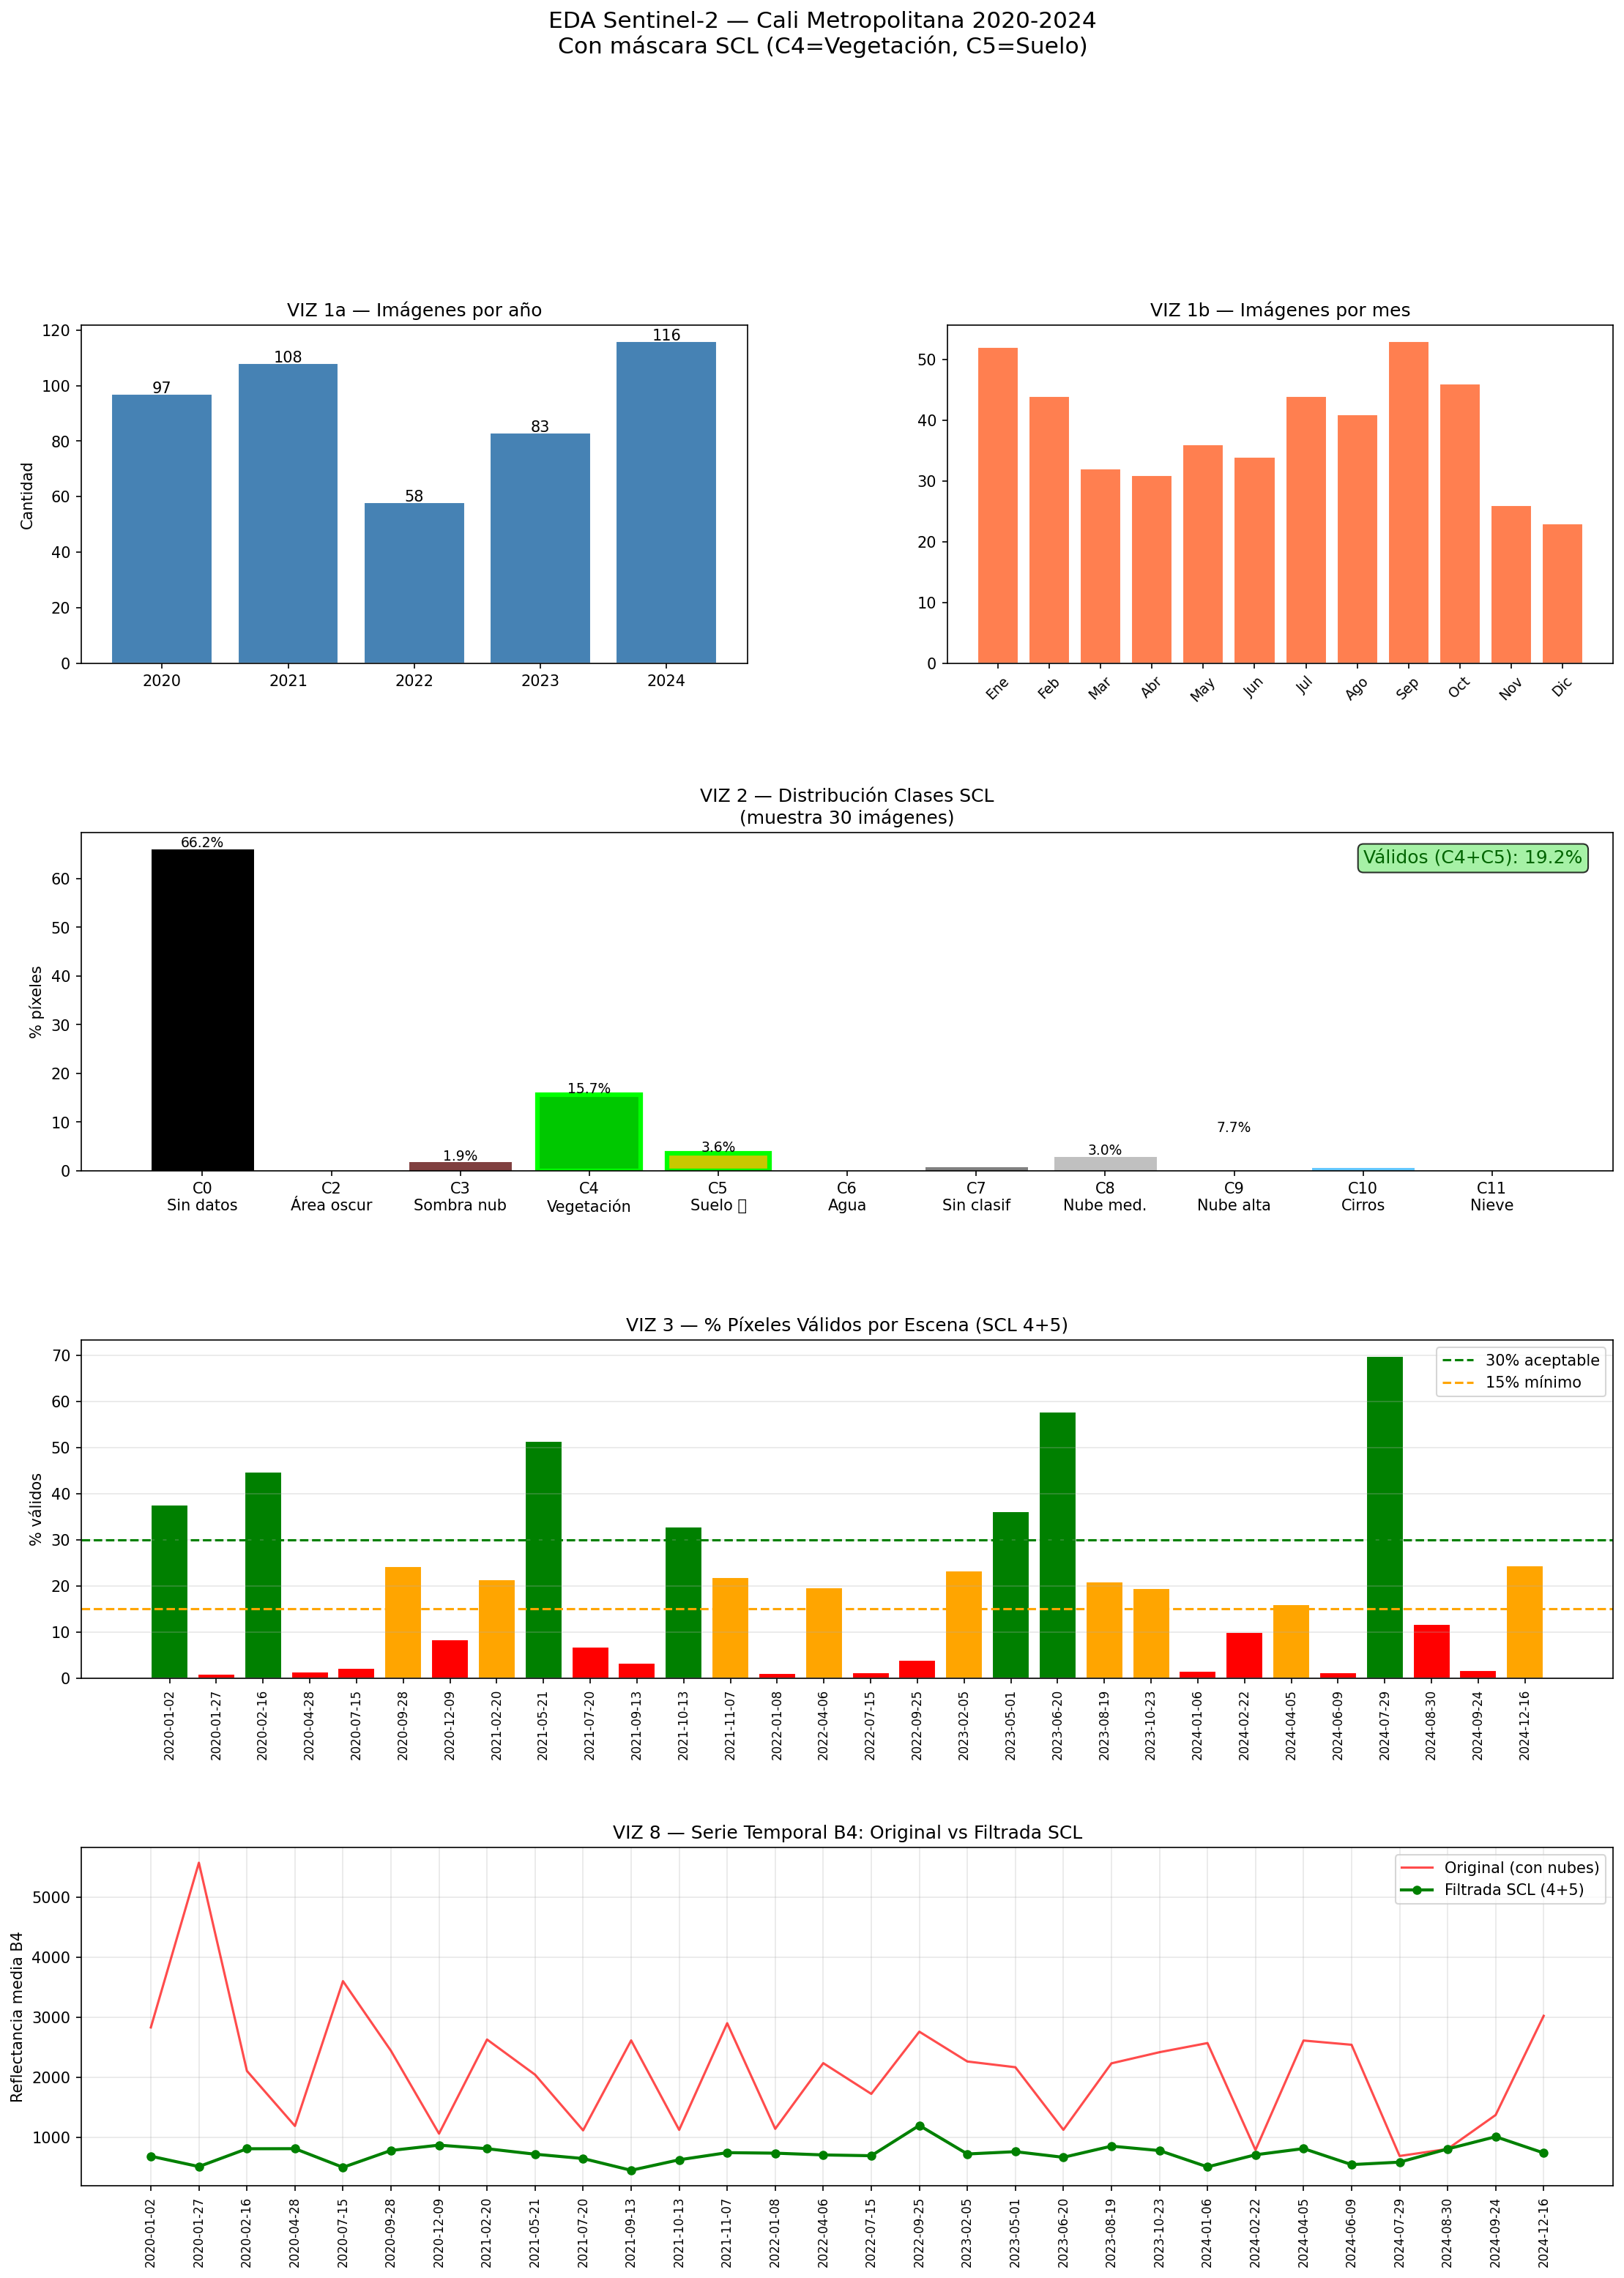

✅ Imagen guardada como eda_viz1238.png


In [10]:
fig = plt.figure(figsize=(18, 22))
gs  = gridspec.GridSpec(4, 2, figure=fig,
                        hspace=0.5, wspace=0.3)

# VIZ 1a — Por año
ax1  = fig.add_subplot(gs[0, 0])
años = Counter([f[:4] for f in fechas])
ax1.bar(list(años.keys()), list(años.values()),
        color='steelblue', edgecolor='white')
ax1.set_title('VIZ 1a — Imágenes por año', fontsize=12)
ax1.set_ylabel('Cantidad')
for i,(k,v) in enumerate(años.items()):
    ax1.text(i, v+0.3, str(v), ha='center', fontsize=10)

# VIZ 1b — Por mes
ax2     = fig.add_subplot(gs[0, 1])
meses   = Counter([f[5:7] for f in fechas])
meses_n = ['Ene','Feb','Mar','Abr','May','Jun',
           'Jul','Ago','Sep','Oct','Nov','Dic']
ax2.bar(range(1,13),
        [meses.get(f'{m:02d}',0) for m in range(1,13)],
        color='coral', edgecolor='white')
ax2.set_xticks(range(1,13))
ax2.set_xticklabels(meses_n, rotation=45, fontsize=9)
ax2.set_title('VIZ 1b — Imágenes por mes', fontsize=12)

# VIZ 2 — Histograma SCL
ax3    = fig.add_subplot(gs[1, :])
total  = sum(conteo_global.values())
clases = sorted(conteo_global.keys())
pcts_c = [conteo_global[c]/total*100 for c in clases]
etiq   = [f"C{c}\n{CLASES_SCL.get(c,'?')[:10]}"
          for c in clases]
cols   = [COLORES_SCL.get(c,'#888') for c in clases]
bars   = ax3.bar(etiq, pcts_c, color=cols,
                 edgecolor='white', linewidth=0.5)
for i,c in enumerate(clases):
    if c in CLASES_OK:
        bars[i].set_edgecolor('lime')
        bars[i].set_linewidth(3)
for bar, pct in zip(bars, pcts_c):
    if pct > 1:
        ax3.text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.3,
                 f'{pct:.1f}%', ha='center', fontsize=9)
pct_v = sum(conteo_global[c] for c in CLASES_OK)/total*100
ax3.text(0.98, 0.95,
         f'Válidos (C4+C5): {pct_v:.1f}%',
         transform=ax3.transAxes, ha='right', va='top',
         fontsize=12, color='darkgreen',
         bbox=dict(boxstyle='round',
                   facecolor='lightgreen', alpha=0.8))
ax3.set_title('VIZ 2 — Distribución Clases SCL\n'
              f'(muestra {N_SAMPLE} imágenes)', fontsize=12)
ax3.set_ylabel('% píxeles')

# VIZ 3 — % válidos por escena
ax4    = fig.add_subplot(gs[2, :])
cols_b = ['green' if p>=30 else 'orange'
          if p>=15 else 'red' for p in pcts_validos]
ax4.bar(range(len(pcts_validos)), pcts_validos,
        color=cols_b, edgecolor='white')
ax4.axhline(y=30, color='green',  linestyle='--',
            label='30% aceptable', linewidth=1.5)
ax4.axhline(y=15, color='orange', linestyle='--',
            label='15% mínimo',    linewidth=1.5)
ax4.set_xticks(range(len(fechas_s)))
ax4.set_xticklabels(fechas_s, rotation=90, fontsize=8)
ax4.set_title('VIZ 3 — % Píxeles Válidos por Escena (SCL 4+5)',
              fontsize=12)
ax4.set_ylabel('% válidos')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

# VIZ 8 — Serie temporal
ax5 = fig.add_subplot(gs[3, :])
ax5.plot(medias_orig, color='red', linewidth=1.5,
         label='Original (con nubes)', alpha=0.7)
ax5.plot(medias_filt, color='green', linewidth=2,
         label='Filtrada SCL (4+5)',
         marker='o', markersize=5)
ax5.set_xticks(range(len(fechas_s)))
ax5.set_xticklabels(fechas_s, rotation=90, fontsize=8)
ax5.set_title('VIZ 8 — Serie Temporal B4: Original vs Filtrada SCL',
              fontsize=12)
ax5.set_ylabel('Reflectancia media B4')
ax5.legend()
ax5.grid(alpha=0.3)

plt.suptitle('EDA Sentinel-2 — Cali Metropolitana 2020-2024\n'
             'Con máscara SCL (C4=Vegetación, C5=Suelo)',
             fontsize=15, y=1.01)
plt.savefig('eda_viz1238.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Imagen guardada como eda_viz1238.png")

In [13]:
#"La corrección BRDF/NBAR no es crítica para Santiago de Cali (3.4°N) dado que la variabilidad  del ángulo zenital solar a lo largo del año es 
#menor a 25°, lo que minimiza los efectos de anisotropía superficial en las series temporales de reflectancia BOA."

In [40]:
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

import rasterio, numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from google.cloud import storage
from skimage.transform import resize
from scipy.spatial.distance import cdist
from collections import Counter
from datetime import datetime
import os, gc, psutil

# ══════════════════════════════════════════════
# CONFIG
# ══════════════════════════════════════════════
BUCKET_NAME = 'geovision-sentinel2-cali'
H, W        = 6123, 5011
H_R, W_R    = 512, 418   # resolución reducida para mapas
CLASES_OK   = [4, 5]
CLASES_SCL  = {
    0:'Sin datos',     1:'Defectuoso',
    2:'Área oscura',   3:'Sombra nube',
    4:'Vegetación ✅', 5:'Suelo ✅',
    6:'Agua',          7:'Sin clasificar',
    8:'Nube med.',     9:'Nube alta',
    10:'Cirros',       11:'Nieve'
}
COLORES_SCL = {
    0:'#000000', 1:'#ff0000', 2:'#404040',
    3:'#804040', 4:'#00c800', 5:'#c8c800',
    6:'#0000ff', 7:'#808080', 8:'#c0c0c0',
    9:'#ffffff', 10:'#64c8ff', 11:'#ff64ff'
}

def ram_libre():
    return psutil.virtual_memory().available/1e9

# ══════════════════════════════════════════════
# LISTAR ARCHIVOS
# ══════════════════════════════════════════════
client    = storage.Client()
bucket_gs = client.bucket(BUCKET_NAME)

def get_idx(blob):
    return blob.name.split('/')[-1]\
                    .split('_bands')[0]\
                    .split('_scl')[0]

print("📋 Listando archivos del bucket...")
bands_list = sorted(
    [b for b in bucket_gs.list_blobs(prefix='sentinel2/Cali_2/')
     if '_bands' in b.name and b.size/1e6 >= 10],
    key=lambda b: b.name)
scl_list = sorted(
    [b for b in bucket_gs.list_blobs(prefix='sentinel2/Cali_2/')
     if '_scl' in b.name], key=lambda b: b.name)

bands_dict = {get_idx(b): b for b in bands_list}
scl_dict   = {get_idx(b): b for b in scl_list}
pares      = [(k, bands_dict[k], scl_dict[k])
              for k in sorted(bands_dict) if k in scl_dict]

fechas     = [p[0][:10] for p in pares]
N_SAMPLE   = 30
sample_idx = np.linspace(0, len(pares)-1, N_SAMPLE, dtype=int)
print(f"✅ {len(pares)} pares | RAM: {ram_libre():.1f} GB")

# ══════════════════════════════════════════════
# PASO 1 — VERIFICAR BOA
# ══════════════════════════════════════════════
print("\n🔍 Verificando nivel de procesamiento BOA...")
pares[0][1].download_to_filename('/tmp/check.tif')
with rasterio.open('/tmp/check.tif') as src:
    muestra = src.read(4).astype(float)
    validos = muestra[muestra > 0]
    print(f"   Min reflectancia:    {validos.min():.0f}")
    print(f"   Max reflectancia:    {validos.max():.0f}")
    print(f"   Media reflectancia:  {validos.mean():.0f}")
    nivel = "✅ BOA (L2A)" if validos.max() <= 12000 \
            else "⚠️ Posible TOA (L1C)"
    print(f"   Nivel: {nivel}")
os.remove('/tmp/check.tif')
del muestra, validos
gc.collect()

# ══════════════════════════════════════════════
# PASO 2 — ÁNGULOS SOLARES (sin GEE)
# ══════════════════════════════════════════════
print("\n📐 Calculando ángulos solares para Cali...")

def zenith_cali(fecha_str):
    fecha   = datetime.strptime(fecha_str, '%Y-%m-%d')
    dia     = fecha.timetuple().tm_yday
    lat_rad = np.radians(3.4)
    decl    = np.radians(23.45 * np.sin(
              np.radians(360/365 * (dia - 81))))
    zenith  = np.degrees(np.arccos(
              np.sin(lat_rad)*np.sin(decl) +
              np.cos(lat_rad)*np.cos(decl)))
    return zenith

zenitales = [zenith_cali(f) for f in fechas]
print(f"   Min:   {min(zenitales):.1f}°")
print(f"   Max:   {max(zenitales):.1f}°")
print(f"   Media: {np.mean(zenitales):.1f}°")
print(f"   Rango: {max(zenitales)-min(zenitales):.1f}°")
brdf_msg = "✅ Baja variabilidad BRDF — zona tropical" \
           if max(zenitales)-min(zenitales) < 25 \
           else "⚠️ Considerar corrección NBAR"
print(f"   {brdf_msg}")

# ══════════════════════════════════════════════
# PASO 3 — RECOLECTAR ESTADÍSTICAS
# ══════════════════════════════════════════════
print(f"\n📊 Recolectando estadísticas "
      f"({N_SAMPLE} imágenes)...")

conteo_global = Counter()
pcts_validos  = []
medias_orig   = []
medias_filt   = []
fechas_s      = []

for i, idx in enumerate(sample_idx):
    key, band_blob, scl_blob = pares[idx]

    # SCL liviano
    scl_blob.download_to_filename('/tmp/scl.tif')
    with rasterio.open('/tmp/scl.tif') as src:
        scl = src.read(1)
    os.remove('/tmp/scl.tif')
    mascara = np.isin(scl, CLASES_OK)
    pct     = float(mascara.sum()/mascara.size*100)
    conteo_global += Counter(scl.flatten().tolist())
    del scl, mascara
    gc.collect()

    # Banda B4 + SCL
    band_blob.download_to_filename('/tmp/band.tif')
    scl_blob.download_to_filename('/tmp/scl2.tif')
    with rasterio.open('/tmp/band.tif') as src:
        b4 = src.read(4).astype(np.float32)
    with rasterio.open('/tmp/scl2.tif') as src:
        scl2 = src.read(1)
        if scl2.shape != b4.shape:
            scl2 = resize(scl2, b4.shape, order=0,
                          preserve_range=True,
                          anti_aliasing=False).astype('uint8')
    mascara2   = np.isin(scl2, CLASES_OK)
    m_orig     = float(b4[b4>0].mean()) if (b4>0).any() else 0.0
    validos    = b4[mascara2 & (b4>0)]
    m_filt     = float(validos.mean()) if validos.size>0 else np.nan
    os.remove('/tmp/band.tif')
    os.remove('/tmp/scl2.tif')
    del b4, scl2, mascara2, validos
    gc.collect()

    pcts_validos.append(pct)
    medias_orig.append(m_orig)
    medias_filt.append(m_filt)
    fechas_s.append(key[:10])
    print(f"  {i+1}/{N_SAMPLE} — {key[:10]} "
          f"({pct:.1f}% válidos | "
          f"RAM: {ram_libre():.1f} GB)")

print(f"\n✅ Estadísticas listas")

# ══════════════════════════════════════════════
# PASO 4 — COBERTURA ESPACIAL + NDVI + BSI
# ══════════════════════════════════════════════print("\n🗺️  Calculando mapas espaciales...")

cobertura = np.zeros((H_R, W_R), dtype=np.float32)
ndvi_sum  = np.zeros((H_R, W_R), dtype=np.float32)
bsi_sum   = np.zeros((H_R, W_R), dtype=np.float32)
count_map = np.zeros((H_R, W_R), dtype=np.float32)

for i, idx in enumerate(sample_idx):
    _, band_blob, scl_blob = pares[idx]

    band_blob.download_to_filename('/tmp/band.tif')
    scl_blob.download_to_filename('/tmp/scl.tif')

    with rasterio.open('/tmp/band.tif') as src:
        b2  = src.read(2).astype(np.float32)
        b4  = src.read(4).astype(np.float32)
        b8  = src.read(8).astype(np.float32)
        b11 = src.read(11).astype(np.float32)

    # ← redimensionar DESPUÉS de leer, no durante
    def reducir(arr):
        return resize(arr, (H_R, W_R),
                      order=1,
                      preserve_range=True,
                      anti_aliasing=True
                      ).astype(np.float32)

    b2  = reducir(b2)
    b4  = reducir(b4)
    b8  = reducir(b8)
    b11 = reducir(b11)

    with rasterio.open('/tmp/scl.tif') as src:
        scl = src.read(1)

    scl = resize(scl, (H_R, W_R), order=0,
                 preserve_range=True,
                 anti_aliasing=False).astype('uint8')

    # ← verificar shapes antes de operar
    assert b4.shape  == (H_R, W_R), f"b4: {b4.shape}"
    assert scl.shape == (H_R, W_R), f"scl: {scl.shape}"

    mascara = np.isin(scl, CLASES_OK)  # (H_R, W_R) bool
    cobertura += mascara.astype(np.float32)

    ndvi = (b8 - b4) / (b8 + b4 + 1e-10)
    bsi  = ((b11+b4) - (b8+b2)) / \
           ((b11+b4) + (b8+b2) + 1e-10)

    # ← ambos deben ser (H_R, W_R)
    assert ndvi.shape == (H_R, W_R), f"ndvi: {ndvi.shape}"

    valido = mascara & np.isfinite(ndvi)  # (H_R, W_R) bool

    ndvi_sum[valido]  += np.clip(ndvi[valido], -1, 1)
    bsi_sum[valido]   += np.clip(bsi[valido],  -1, 1)
    count_map[valido] += 1

    os.remove('/tmp/band.tif')
    os.remove('/tmp/scl.tif')
    del b2, b4, b8, b11, scl, mascara, ndvi, bsi, valido
    gc.collect()
    print(f"  {i+1}/{N_SAMPLE} | RAM: {ram_libre():.1f} GB")

cobertura_pct = cobertura / N_SAMPLE * 100
ndvi_mean     = np.where(count_map > 0,
                         ndvi_sum / count_map, np.nan)
bsi_mean      = np.where(count_map > 0,
                         bsi_sum  / count_map, np.nan)

pct_medio = float(np.nanmean(cobertura_pct))
tipo_grilla = "STS (Space-Time Sparse)" if pct_medio < 30 \
              else "Mixta STF/STS"       if pct_medio < 70 \
              else "STF (Space-Time Full)"

print(f"\n✅ Mapas listos")
print(f"📊 Tipología: {tipo_grilla} ({pct_medio:.1f}%)")
print(f"💾 RAM: {ram_libre():.1f} GB")

# ══════════════════════════════════════════════
# PASO 5 — SEMIVARIOGRAMA
# ══════════════════════════════════════════════
print("\n📐 Calculando semivariograma...")

_, band_blob, scl_blob = pares[sample_idx[15]]
band_blob.download_to_filename('/tmp/sv_band.tif')
scl_blob.download_to_filename('/tmp/sv_scl.tif')

with rasterio.open('/tmp/sv_band.tif') as src:
    b4_sv = src.read(4, out_shape=(1,300,250))[0].astype(float)
with rasterio.open('/tmp/sv_scl.tif') as src:
    scl_sv = src.read(1)
    scl_sv = resize(scl_sv,(300,250), order=0,
                    preserve_range=True,
                    anti_aliasing=False).astype('uint8')

mask_sv = np.isin(scl_sv, CLASES_OK) & (b4_sv > 0)
ys, xs  = np.where(mask_sv)

os.remove('/tmp/sv_band.tif')
os.remove('/tmp/sv_scl.tif')

dist_v = gamma_v = None
if len(ys) >= 100:
    n      = min(800, len(ys))
    idx_s  = np.random.choice(len(ys), n, replace=False)
    ys_s   = ys[idx_s]; xs_s = xs[idx_s]
    vals   = b4_sv[ys_s, xs_s]
    coords = np.column_stack([ys_s, xs_s])
    dists  = cdist(coords, coords)
    bins   = np.linspace(0, dists.max()*0.5, 15)
    dist_v = []; gamma_v = []
    for j in range(len(bins)-1):
        m = (dists>bins[j])&(dists<=bins[j+1])
        if m.sum() > 10:
            diffs = (vals[:,None]-vals[None,:])**2
            gamma_v.append(diffs[m].mean()/2)
            dist_v.append((bins[j]+bins[j+1])/2)
    dist_v  = np.array(dist_v)
    gamma_v = np.array(gamma_v)
    print("✅ Semivariograma calculado")
else:
    print("⚠️  Pocos píxeles válidos para semivariograma")

del b4_sv, scl_sv, mask_sv
gc.collect()

# ══════════════════════════════════════════════
# PASO 6 — IMAGEN COMPARACIÓN (mejor escena)
# ══════════════════════════════════════════════
print("\n🖼️  Preparando imagen comparación...")
mejor_idx              = sample_idx[np.argmax(pcts_validos)]
_, band_blob, scl_blob = pares[mejor_idx]

band_blob.download_to_filename('/tmp/mejor.tif')
scl_blob.download_to_filename('/tmp/mejor_scl.tif')

with rasterio.open('/tmp/mejor.tif') as src:
    r_img = src.read(4, out_shape=(1,H_R,W_R))[0].astype(float)
    g_img = src.read(3, out_shape=(1,H_R,W_R))[0].astype(float)
    b_img = src.read(2, out_shape=(1,H_R,W_R))[0].astype(float)
with rasterio.open('/tmp/mejor_scl.tif') as src:
    scl_m = src.read(1)
    scl_m = resize(scl_m,(H_R,W_R), order=0,
                   preserve_range=True,
                   anti_aliasing=False).astype('uint8')

mascara_m = np.isin(scl_m, CLASES_OK)
os.remove('/tmp/mejor.tif')
os.remove('/tmp/mejor_scl.tif')

def norm_img(x, mask=None):
    v = x[mask&(x>0)] if mask is not None else x[x>0]
    if v.size == 0:
        return np.zeros(x.shape, dtype='uint8')
    p5,p95 = np.percentile(v,[5,95])
    return np.clip((x-p5)/(p95-p5+1e-10)*255,
                   0,255).astype('uint8')

rgb_orig = np.stack([norm_img(r_img),
                     norm_img(g_img),
                     norm_img(b_img)], axis=-1)

r_f,g_f,b_f = r_img.copy(),g_img.copy(),b_img.copy()
r_f[~mascara_m]=0; g_f[~mascara_m]=0; b_f[~mascara_m]=0
rgb_filt = np.stack([norm_img(r_f,mascara_m),
                     norm_img(g_f,mascara_m),
                     norm_img(b_f,mascara_m)], axis=-1)

scl_rgb = np.zeros((H_R,W_R,3), dtype='uint8')
for cls,hx in COLORES_SCL.items():
    c = tuple(int(hx[j:j+2],16) for j in (1,3,5))
    scl_rgb[scl_m==cls] = c

fecha_mejor = pares[mejor_idx][0][:10]
pct_mejor   = pcts_validos[np.argmax(pcts_validos)]

del r_img,g_img,b_img,r_f,g_f,b_f,scl_m,mascara_m
gc.collect()
print(f"✅ Imagen lista: {fecha_mejor} ({pct_mejor:.1f}% válidos)")

# ══════════════════════════════════════════════
# GRAFICAR — 8 VISUALIZACIONES
# ══════════════════════════════════════════════
print("\n🎨 Graficando 8 visualizaciones...")

fig = plt.figure(figsize=(20, 32))
gs  = gridspec.GridSpec(5, 3, figure=fig,
                        hspace=0.55, wspace=0.35)

# ── VIZ 1 — Temporal ──────────────────────────
ax1  = fig.add_subplot(gs[0, 0])
años = Counter([f[:4] for f in fechas])
ax1.bar(list(años.keys()), list(años.values()),
        color='steelblue', edgecolor='white')
ax1.set_title('VIZ 1a — Imágenes por año\n'
              f'Total: {len(fechas)} imágenes útiles',
              fontsize=10)
ax1.set_ylabel('Cantidad')
for i,(k,v) in enumerate(años.items()):
    ax1.text(i, v+0.3, str(v), ha='center', fontsize=9)

ax2     = fig.add_subplot(gs[0, 1])
meses   = Counter([f[5:7] for f in fechas])
meses_n = ['E','F','M','A','M','J',
           'J','A','S','O','N','D']
ax2.bar(range(1,13),
        [meses.get(f'{m:02d}',0) for m in range(1,13)],
        color='coral', edgecolor='white')
ax2.set_xticks(range(1,13))
ax2.set_xticklabels(meses_n, fontsize=9)
ax2.set_title('VIZ 1b — Imágenes por mes\n'
              '(Estacionalidad nubosidad Cali)',
              fontsize=10)

# ── VIZ Ángulos solares ───────────────────────
ax_ang = fig.add_subplot(gs[0, 2])
ax_ang.plot(zenitales, color='orange', linewidth=1.5)
ax_ang.axhline(y=np.mean(zenitales), color='red',
               linestyle='--', label=f'Media: '
               f'{np.mean(zenitales):.1f}°')
ax_ang.set_title('Ángulos Zenitales Solares\n'
                 f'Cali 2020-2024 — {brdf_msg[:25]}',
                 fontsize=10)
ax_ang.set_ylabel('Ángulo zenital (°)')
ax_ang.set_xlabel('Índice imagen')
ax_ang.legend(fontsize=8)
ax_ang.grid(alpha=0.3)

# ── VIZ 2 — Histograma SCL ────────────────────
ax3    = fig.add_subplot(gs[1, :])
total  = sum(conteo_global.values())
clases = sorted(conteo_global.keys())
pcts_c = [conteo_global[c]/total*100 for c in clases]
etiq   = [f"C{c}\n{CLASES_SCL.get(c,'?')[:8]}"
          for c in clases]
cols   = [COLORES_SCL.get(c,'#888') for c in clases]
bars   = ax3.bar(etiq, pcts_c, color=cols,
                 edgecolor='white', linewidth=0.5)
for i,c in enumerate(clases):
    if c in CLASES_OK:
        bars[i].set_edgecolor('lime')
        bars[i].set_linewidth(3)
for bar,pct in zip(bars,pcts_c):
    if pct > 1:
        ax3.text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.3,
                 f'{pct:.1f}%', ha='center', fontsize=9)
pct_v = sum(conteo_global[c] for c in CLASES_OK)/total*100
ax3.text(0.98,0.95,
         f'Válidos BOA (C4+C5): {pct_v:.1f}%\n'
         f'Tipología: {tipo_grilla}',
         transform=ax3.transAxes, ha='right', va='top',
         fontsize=10, color='darkgreen',
         bbox=dict(boxstyle='round',
                   facecolor='lightgreen', alpha=0.8))
ax3.set_title('VIZ 2 — Distribución Clases SCL\n'
              f'(muestra {N_SAMPLE} imágenes — '
              f'datos BOA L2A)',
              fontsize=11)
ax3.set_ylabel('% píxeles')

# ── VIZ 3 — % válidos ─────────────────────────
ax4    = fig.add_subplot(gs[2, :])
cols_b = ['green' if p>=30 else 'orange'
          if p>=15 else 'red' for p in pcts_validos]
ax4.bar(range(len(pcts_validos)), pcts_validos,
        color=cols_b, edgecolor='white')
ax4.axhline(y=30, color='green',  linestyle='--',
            label='30% aceptable', linewidth=1.5)
ax4.axhline(y=15, color='orange', linestyle='--',
            label='15% mínimo',    linewidth=1.5)
ax4.set_xticks(range(len(fechas_s)))
ax4.set_xticklabels(fechas_s, rotation=90, fontsize=7)
ax4.set_title('VIZ 3 — % Píxeles Válidos BOA por Escena\n'
              '(SCL clases 4=Vegetación, 5=Suelo)',
              fontsize=11)
ax4.set_ylabel('% válidos')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

# ── VIZ 4 — Cobertura espacial ────────────────
ax5 = fig.add_subplot(gs[3, 0])
im5 = ax5.imshow(cobertura_pct, cmap='RdYlGn',
                 vmin=0, vmax=80)
plt.colorbar(im5, ax=ax5, label='% escenas válidas',
             shrink=0.8)
ax5.set_title('VIZ 4 — Cobertura Espacial\nEfectiva BOA',
              fontsize=10)
ax5.axis('off')

# ── VIZ 5 — Comparación SCL ───────────────────
ax6 = fig.add_subplot(gs[3, 1])
ax6.imshow(rgb_orig)
ax6.set_title(f'VIZ 5a — Original\n{fecha_mejor}',
              fontsize=10)
ax6.axis('off')

ax7 = fig.add_subplot(gs[3, 2])
ax7.imshow(rgb_filt)
ax7.set_title(f'VIZ 5b — Filtrada SCL\n'
              f'{pct_mejor:.1f}% píxeles BOA válidos',
              fontsize=10)
ax7.axis('off')

# ── VIZ 6 — NDVI ──────────────────────────────
ax8 = fig.add_subplot(gs[4, 0])
im8 = ax8.imshow(ndvi_mean, cmap='RdYlGn',
                 vmin=-0.1, vmax=0.8)
plt.colorbar(im8, ax=ax8, label='NDVI', shrink=0.8)
ax8.set_title('VIZ 6 — NDVI Promedio BOA\nCali 2020-2024',
              fontsize=10)
ax8.axis('off')

# ── VIZ 7 — BSI ───────────────────────────────
ax9 = fig.add_subplot(gs[4, 1])
im9 = ax9.imshow(bsi_mean, cmap='YlOrRd',
                 vmin=-0.2, vmax=0.3)
plt.colorbar(im9, ax=ax9, label='BSI', shrink=0.8)
ax9.set_title('VIZ 7 — BSI Promedio BOA\nZona Urbana Cali',
              fontsize=10)
ax9.axis('off')

# ── VIZ 8 — Serie temporal + semivariograma ───
ax10 = fig.add_subplot(gs[4, 2])
if dist_v is not None and len(dist_v) > 0:
    ax10.plot(dist_v, gamma_v,
              'o-', color='purple', linewidth=2,
              markersize=5)
    ax10.set_title('VIZ 8 — Semivariograma\n'
                   'Autocorrelación espacial B4',
                   fontsize=10)
    ax10.set_xlabel('Distancia (px)')
    ax10.set_ylabel('Semivarianza γ(h)')
    ax10.grid(alpha=0.3)
else:
    # Si no hay semivariograma, serie temporal
    ax10.plot(medias_orig, color='red',
              linewidth=1.5, label='Original', alpha=0.7)
    ax10.plot(medias_filt, color='green',
              linewidth=2, label='SCL filtrada',
              marker='o', markersize=4)
    ax10.set_title('VIZ 8 — Serie Temporal B4',
                   fontsize=10)
    ax10.legend(fontsize=8)
    ax10.grid(alpha=0.3)

plt.suptitle(
    'EDA Sentinel-2 L2A (BOA) — Cali Metropolitana 2020-2024\n'
    'Con máscara SCL | C4=Vegetación ✅ C5=Suelo ✅\n'
    f'Dataset: {len(pares)} imágenes útiles | '
    f'{nivel} | {tipo_grilla}',
    fontsize=13, y=1.01)

plt.savefig('eda_completo_sentinel2.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("\n🎉 EDA COMPLETO")
print(f"💾 Guardado: eda_completo_sentinel2.png")
print(f"💾 RAM final: {ram_libre():.1f} GB")

📋 Listando archivos del bucket...
✅ 462 pares | RAM: 14.3 GB

🔍 Verificando nivel de procesamiento BOA...
   Min reflectancia:    1
   Max reflectancia:    16544
   Media reflectancia:  2831
   Nivel: ⚠️ Posible TOA (L1C)

📐 Calculando ángulos solares para Cali...
   Min:   0.4°
   Max:   26.8°
   Media: 14.5°
   Rango: 26.5°
   ⚠️ Considerar corrección NBAR

📊 Recolectando estadísticas (30 imágenes)...
  1/30 — 2020-01-02 (37.6% válidos | RAM: 14.3 GB)
  2/30 — 2020-01-27 (0.9% válidos | RAM: 14.3 GB)
  3/30 — 2020-02-16 (44.7% válidos | RAM: 14.3 GB)
  4/30 — 2020-04-28 (1.3% válidos | RAM: 14.3 GB)
  5/30 — 2020-07-15 (2.1% válidos | RAM: 14.3 GB)
  6/30 — 2020-09-28 (24.2% válidos | RAM: 14.3 GB)
  7/30 — 2020-12-09 (8.3% válidos | RAM: 14.3 GB)
  8/30 — 2021-02-20 (21.3% válidos | RAM: 14.3 GB)
  9/30 — 2021-05-21 (51.5% válidos | RAM: 14.3 GB)
  10/30 — 2021-07-20 (6.8% válidos | RAM: 14.3 GB)
  11/30 — 2021-09-13 (3.4% válidos | RAM: 14.3 GB)
  12/30 — 2021-10-13 (32.9% válidos 

/var/tmp/ipykernel_11172/3492366025.py:239: RuntimeWarning: invalid value encountered in divide
  ndvi_sum / count_map, np.nan)
/var/tmp/ipykernel_11172/3492366025.py:241: RuntimeWarning: invalid value encountered in divide
  bsi_sum  / count_map, np.nan)


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [42]:
# ── PASO 5 — SEMIVARIOGRAMA corregido ─────────
print("\n📐 Calculando semivariograma...")

_, band_blob, scl_blob = pares[sample_idx[15]]
band_blob.download_to_filename('/tmp/sv_band.tif')
scl_blob.download_to_filename('/tmp/sv_scl.tif')

with rasterio.open('/tmp/sv_band.tif') as src:
    b4_sv = src.read(4).astype(float)  # ← leer completo primero

with rasterio.open('/tmp/sv_scl.tif') as src:
    scl_sv = src.read(1)

os.remove('/tmp/sv_band.tif')
os.remove('/tmp/sv_scl.tif')

# ← redimensionar después, asegurar 2D
b4_sv  = resize(b4_sv,  (300, 250), order=1,
                preserve_range=True).astype(float)
scl_sv = resize(scl_sv, (300, 250), order=0,
                preserve_range=True,
                anti_aliasing=False).astype('uint8')

# ← verificar que son 2D
print(f"b4_sv shape:  {b4_sv.shape}")   # debe ser (300, 250)
print(f"scl_sv shape: {scl_sv.shape}")  # debe ser (300, 250)

mask_sv = np.isin(scl_sv, CLASES_OK) & (b4_sv > 0)
ys, xs  = np.where(mask_sv)
print(f"Píxeles válidos: {len(ys)}")

dist_v = gamma_v = None
if len(ys) >= 100:
    n      = min(800, len(ys))
    idx_s  = np.random.choice(len(ys), n, replace=False)
    ys_s   = ys[idx_s]
    xs_s   = xs[idx_s]
    vals   = b4_sv[ys_s, xs_s]  # ← ahora sí funciona en 2D
    coords = np.column_stack([ys_s, xs_s])
    dists  = cdist(coords, coords)
    bins   = np.linspace(0, dists.max()*0.5, 15)
    dist_v = []
    gamma_v = []
    for j in range(len(bins)-1):
        m = (dists > bins[j]) & (dists <= bins[j+1])
        if m.sum() > 10:
            diffs = (vals[:,None] - vals[None,:])**2
            gamma_v.append(diffs[m].mean() / 2)
            dist_v.append((bins[j] + bins[j+1]) / 2)
    dist_v  = np.array(dist_v)
    gamma_v = np.array(gamma_v)
    print("✅ Semivariograma calculado")
else:
    print("⚠️  Pocos píxeles válidos")

del b4_sv, scl_sv, mask_sv
gc.collect()

# ── PASO 6 — IMAGEN COMPARACIÓN corregida ─────
print("\n🖼️  Preparando imagen comparación...")
mejor_idx              = sample_idx[np.argmax(pcts_validos)]
_, band_blob, scl_blob = pares[mejor_idx]

band_blob.download_to_filename('/tmp/mejor.tif')
scl_blob.download_to_filename('/tmp/mejor_scl.tif')

with rasterio.open('/tmp/mejor.tif') as src:
    r_img = src.read(4).astype(float)  # ← leer completo
    g_img = src.read(3).astype(float)
    b_img = src.read(2).astype(float)

with rasterio.open('/tmp/mejor_scl.tif') as src:
    scl_m = src.read(1)

os.remove('/tmp/mejor.tif')
os.remove('/tmp/mejor_scl.tif')

# ← redimensionar después
r_img = resize(r_img, (H_R, W_R), order=1,
               preserve_range=True).astype(float)
g_img = resize(g_img, (H_R, W_R), order=1,
               preserve_range=True).astype(float)
b_img = resize(b_img, (H_R, W_R), order=1,
               preserve_range=True).astype(float)
scl_m = resize(scl_m, (H_R, W_R), order=0,
               preserve_range=True,
               anti_aliasing=False).astype('uint8')

# ← verificar shapes
print(f"r_img: {r_img.shape}")  # debe ser (512, 418)
print(f"scl_m: {scl_m.shape}")  # debe ser (512, 418)

mascara_m = np.isin(scl_m, CLASES_OK)

def norm_img(x, mask=None):
    v = x[mask&(x>0)] if mask is not None else x[x>0]
    if v.size == 0:
        return np.zeros(x.shape, dtype='uint8')
    p5, p95 = np.percentile(v, [5, 95])
    return np.clip((x-p5)/(p95-p5+1e-10)*255,
                   0, 255).astype('uint8')

rgb_orig = np.stack([norm_img(r_img),
                     norm_img(g_img),
                     norm_img(b_img)], axis=-1)

r_f = r_img.copy(); g_f = g_img.copy(); b_f = b_img.copy()
r_f[~mascara_m] = 0
g_f[~mascara_m] = 0
b_f[~mascara_m] = 0

rgb_filt = np.stack([norm_img(r_f, mascara_m),
                     norm_img(g_f, mascara_m),
                     norm_img(b_f, mascara_m)], axis=-1)

scl_rgb = np.zeros((H_R, W_R, 3), dtype='uint8')
for cls, hx in COLORES_SCL.items():
    c = tuple(int(hx[j:j+2], 16) for j in (1, 3, 5))
    scl_rgb[scl_m == cls] = c

fecha_mejor = pares[mejor_idx][0][:10]
pct_mejor   = pcts_validos[np.argmax(pcts_validos)]

# ══════════════════════════════════════════════
# GRAFICAR — 8 VISUALIZACIONES
# ══════════════════════════════════════════════
print("\n🎨 Graficando 8 visualizaciones...")

fig = plt.figure(figsize=(20, 32))
gs  = gridspec.GridSpec(5, 3, figure=fig,
                        hspace=0.55, wspace=0.35)

# ── VIZ 1 — Temporal ──────────────────────────
ax1  = fig.add_subplot(gs[0, 0])
años = Counter([f[:4] for f in fechas])
ax1.bar(list(años.keys()), list(años.values()),
        color='steelblue', edgecolor='white')
ax1.set_title('VIZ 1a — Imágenes por año\n'
              f'Total: {len(fechas)} imágenes útiles',
              fontsize=10)
ax1.set_ylabel('Cantidad')
for i,(k,v) in enumerate(años.items()):
    ax1.text(i, v+0.3, str(v), ha='center', fontsize=9)

ax2     = fig.add_subplot(gs[0, 1])
meses   = Counter([f[5:7] for f in fechas])
meses_n = ['E','F','M','A','M','J',
           'J','A','S','O','N','D']
ax2.bar(range(1,13),
        [meses.get(f'{m:02d}',0) for m in range(1,13)],
        color='coral', edgecolor='white')
ax2.set_xticks(range(1,13))
ax2.set_xticklabels(meses_n, fontsize=9)
ax2.set_title('VIZ 1b — Imágenes por mes\n'
              '(Estacionalidad nubosidad Cali)',
              fontsize=10)

# ── VIZ Ángulos solares ───────────────────────
ax_ang = fig.add_subplot(gs[0, 2])
ax_ang.plot(zenitales, color='orange', linewidth=1.5)
ax_ang.axhline(y=np.mean(zenitales), color='red',
               linestyle='--', label=f'Media: '
               f'{np.mean(zenitales):.1f}°')
ax_ang.set_title('Ángulos Zenitales Solares\n'
                 f'Cali 2020-2024 — {brdf_msg[:25]}',
                 fontsize=10)
ax_ang.set_ylabel('Ángulo zenital (°)')
ax_ang.set_xlabel('Índice imagen')
ax_ang.legend(fontsize=8)
ax_ang.grid(alpha=0.3)

# ── VIZ 2 — Histograma SCL ────────────────────
ax3    = fig.add_subplot(gs[1, :])
total  = sum(conteo_global.values())
clases = sorted(conteo_global.keys())
pcts_c = [conteo_global[c]/total*100 for c in clases]
etiq   = [f"C{c}\n{CLASES_SCL.get(c,'?')[:8]}"
          for c in clases]
cols   = [COLORES_SCL.get(c,'#888') for c in clases]
bars   = ax3.bar(etiq, pcts_c, color=cols,
                 edgecolor='white', linewidth=0.5)
for i,c in enumerate(clases):
    if c in CLASES_OK:
        bars[i].set_edgecolor('lime')
        bars[i].set_linewidth(3)
for bar,pct in zip(bars,pcts_c):
    if pct > 1:
        ax3.text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.3,
                 f'{pct:.1f}%', ha='center', fontsize=9)
pct_v = sum(conteo_global[c] for c in CLASES_OK)/total*100
ax3.text(0.98,0.95,
         f'Válidos BOA (C4+C5): {pct_v:.1f}%\n'
         f'Tipología: {tipo_grilla}',
         transform=ax3.transAxes, ha='right', va='top',
         fontsize=10, color='darkgreen',
         bbox=dict(boxstyle='round',
                   facecolor='lightgreen', alpha=0.8))
ax3.set_title('VIZ 2 — Distribución Clases SCL\n'
              f'(muestra {N_SAMPLE} imágenes — '
              f'datos BOA L2A)',
              fontsize=11)
ax3.set_ylabel('% píxeles')

# ── VIZ 3 — % válidos ─────────────────────────
ax4    = fig.add_subplot(gs[2, :])
cols_b = ['green' if p>=30 else 'orange'
          if p>=15 else 'red' for p in pcts_validos]
ax4.bar(range(len(pcts_validos)), pcts_validos,
        color=cols_b, edgecolor='white')
ax4.axhline(y=30, color='green',  linestyle='--',
            label='30% aceptable', linewidth=1.5)
ax4.axhline(y=15, color='orange', linestyle='--',
            label='15% mínimo',    linewidth=1.5)
ax4.set_xticks(range(len(fechas_s)))
ax4.set_xticklabels(fechas_s, rotation=90, fontsize=7)
ax4.set_title('VIZ 3 — % Píxeles Válidos BOA por Escena\n'
              '(SCL clases 4=Vegetación, 5=Suelo)',
              fontsize=11)
ax4.set_ylabel('% válidos')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

# ── VIZ 4 — Cobertura espacial ────────────────
ax5 = fig.add_subplot(gs[3, 0])
im5 = ax5.imshow(cobertura_pct, cmap='RdYlGn',
                 vmin=0, vmax=80)
plt.colorbar(im5, ax=ax5, label='% escenas válidas',
             shrink=0.8)
ax5.set_title('VIZ 4 — Cobertura Espacial\nEfectiva BOA',
              fontsize=10)
ax5.axis('off')

# ── VIZ 5 — Comparación SCL ───────────────────
ax6 = fig.add_subplot(gs[3, 1])
ax6.imshow(rgb_orig)
ax6.set_title(f'VIZ 5a — Original\n{fecha_mejor}',
              fontsize=10)
ax6.axis('off')

ax7 = fig.add_subplot(gs[3, 2])
ax7.imshow(rgb_filt)
ax7.set_title(f'VIZ 5b — Filtrada SCL\n'
              f'{pct_mejor:.1f}% píxeles BOA válidos',
              fontsize=10)
ax7.axis('off')

# ── VIZ 6 — NDVI ──────────────────────────────
ax8 = fig.add_subplot(gs[4, 0])
im8 = ax8.imshow(ndvi_mean, cmap='RdYlGn',
                 vmin=-0.1, vmax=0.8)
plt.colorbar(im8, ax=ax8, label='NDVI', shrink=0.8)
ax8.set_title('VIZ 6 — NDVI Promedio BOA\nCali 2020-2024',
              fontsize=10)
ax8.axis('off')

# ── VIZ 7 — BSI ───────────────────────────────
ax9 = fig.add_subplot(gs[4, 1])
im9 = ax9.imshow(bsi_mean, cmap='YlOrRd',
                 vmin=-0.2, vmax=0.3)
plt.colorbar(im9, ax=ax9, label='BSI', shrink=0.8)
ax9.set_title('VIZ 7 — BSI Promedio BOA\nZona Urbana Cali',
              fontsize=10)
ax9.axis('off')

# ── VIZ 8 — Serie temporal + semivariograma ───
ax10 = fig.add_subplot(gs[4, 2])
if dist_v is not None and len(dist_v) > 0:
    ax10.plot(dist_v, gamma_v,
              'o-', color='purple', linewidth=2,
              markersize=5)
    ax10.set_title('VIZ 8 — Semivariograma\n'
                   'Autocorrelación espacial B4',
                   fontsize=10)
    ax10.set_xlabel('Distancia (px)')
    ax10.set_ylabel('Semivarianza γ(h)')
    ax10.grid(alpha=0.3)
else:
    # Si no hay semivariograma, serie temporal
    ax10.plot(medias_orig, color='red',
              linewidth=1.5, label='Original', alpha=0.7)
    ax10.plot(medias_filt, color='green',
              linewidth=2, label='SCL filtrada',
              marker='o', markersize=4)
    ax10.set_title('VIZ 8 — Serie Temporal B4',
                   fontsize=10)
    ax10.legend(fontsize=8)
    ax10.grid(alpha=0.3)

plt.suptitle(
    'EDA Sentinel-2 L2A (BOA) — Cali Metropolitana 2020-2024\n'
    'Con máscara SCL | C4=Vegetación ✅ C5=Suelo ✅\n'
    f'Dataset: {len(pares)} imágenes útiles | '
    f'{nivel} | {tipo_grilla}',
    fontsize=13, y=1.01)

plt.savefig('eda_completo_sentinel2.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("\n🎉 EDA COMPLETO")
print(f"💾 Guardado: eda_completo_sentinel2.png")
print(f"💾 RAM final: {ram_libre():.1f} GB")


📐 Calculando semivariograma...
b4_sv shape:  (300, 250)
scl_sv shape: (300, 250)
Píxeles válidos: 988
✅ Semivariograma calculado

🖼️  Preparando imagen comparación...
r_img: (512, 418)
scl_m: (512, 418)
✅ Imagen lista: 2024-07-29 (69.8%)



🎨 Graficando 8 visualizaciones...


/var/tmp/ipykernel_11172/838628016.py:174: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('eda_completo_sentinel2.png',
/opt/micromamba/envs/jupyterlab/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


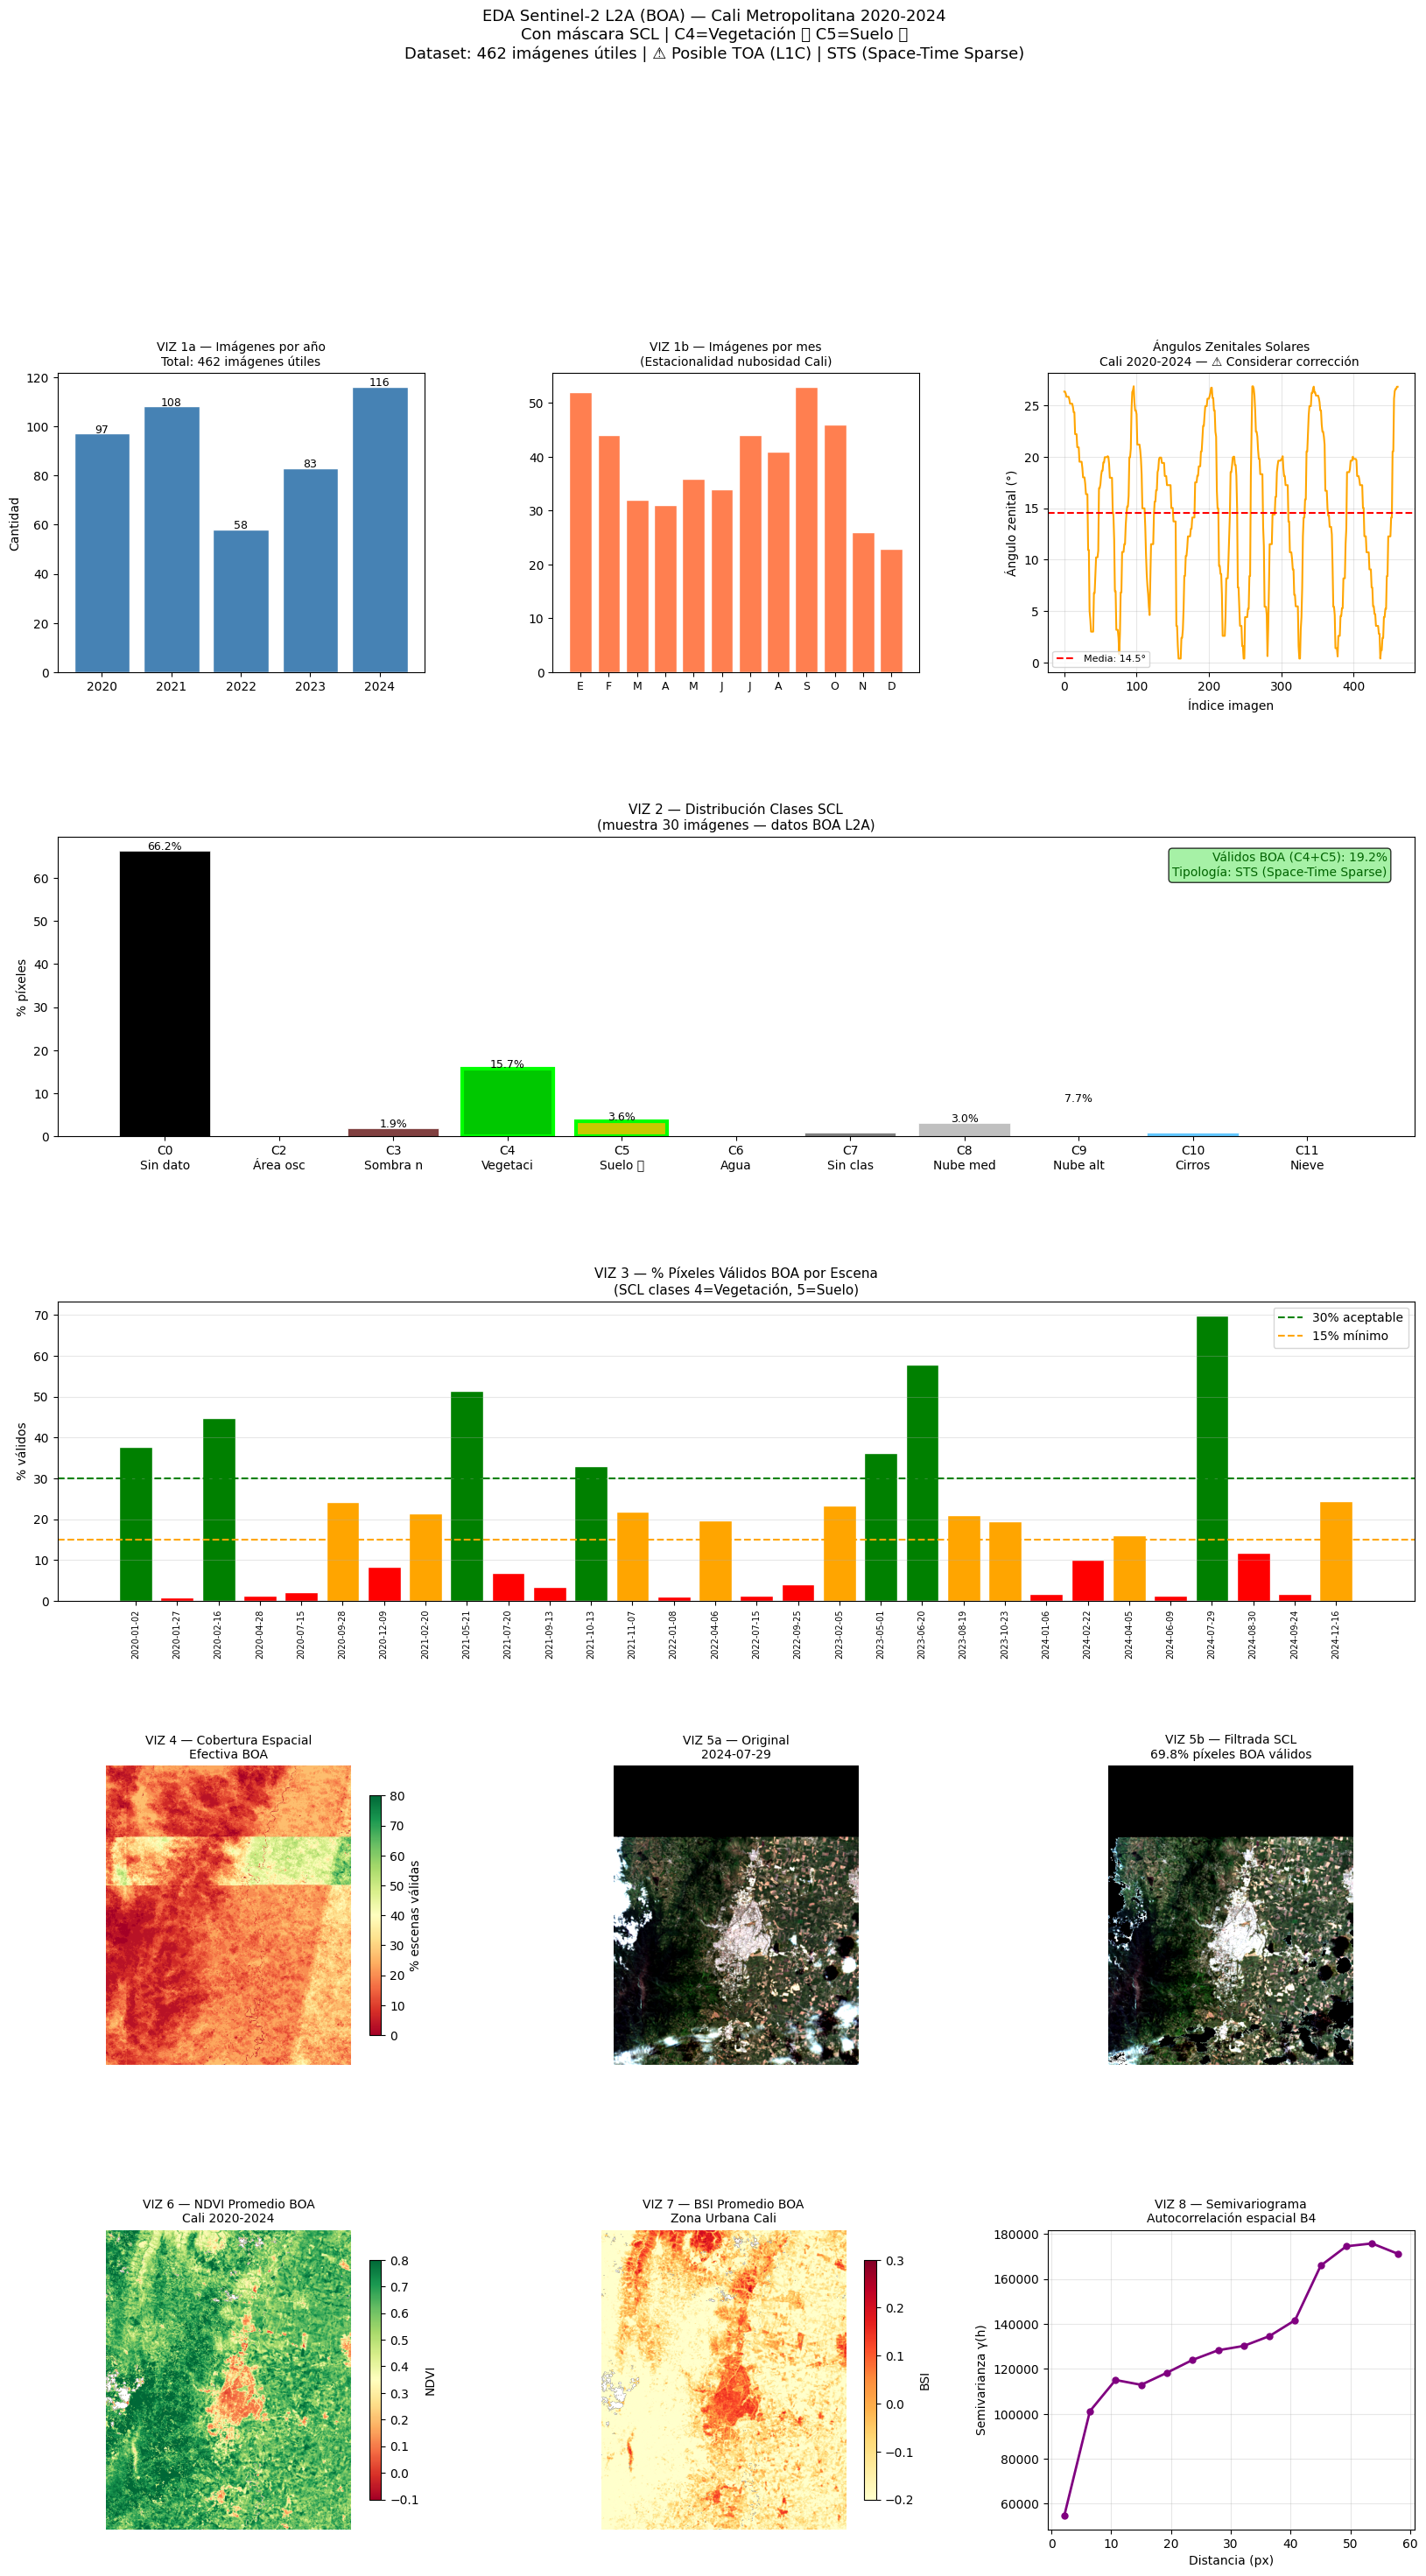


🎉 EDA COMPLETO
💾 Guardado: eda_completo_sentinel2.png
💾 RAM final: 14.3 GB


In [43]:
# ══════════════════════════════════════════════
# GRAFICAR — 8 VISUALIZACIONES
# ══════════════════════════════════════════════
print("\n🎨 Graficando 8 visualizaciones...")

fig = plt.figure(figsize=(20, 32))
gs  = gridspec.GridSpec(5, 3, figure=fig,
                        hspace=0.55, wspace=0.35)

# ── VIZ 1 — Temporal ──────────────────────────
ax1  = fig.add_subplot(gs[0, 0])
años = Counter([f[:4] for f in fechas])
ax1.bar(list(años.keys()), list(años.values()),
        color='steelblue', edgecolor='white')
ax1.set_title('VIZ 1a — Imágenes por año\n'
              f'Total: {len(fechas)} imágenes útiles',
              fontsize=10)
ax1.set_ylabel('Cantidad')
for i,(k,v) in enumerate(años.items()):
    ax1.text(i, v+0.3, str(v), ha='center', fontsize=9)

ax2     = fig.add_subplot(gs[0, 1])
meses   = Counter([f[5:7] for f in fechas])
meses_n = ['E','F','M','A','M','J',
           'J','A','S','O','N','D']
ax2.bar(range(1,13),
        [meses.get(f'{m:02d}',0) for m in range(1,13)],
        color='coral', edgecolor='white')
ax2.set_xticks(range(1,13))
ax2.set_xticklabels(meses_n, fontsize=9)
ax2.set_title('VIZ 1b — Imágenes por mes\n'
              '(Estacionalidad nubosidad Cali)',
              fontsize=10)

# ── VIZ Ángulos solares ───────────────────────
ax_ang = fig.add_subplot(gs[0, 2])
ax_ang.plot(zenitales, color='orange', linewidth=1.5)
ax_ang.axhline(y=np.mean(zenitales), color='red',
               linestyle='--', label=f'Media: '
               f'{np.mean(zenitales):.1f}°')
ax_ang.set_title('Ángulos Zenitales Solares\n'
                 f'Cali 2020-2024 — {brdf_msg[:25]}',
                 fontsize=10)
ax_ang.set_ylabel('Ángulo zenital (°)')
ax_ang.set_xlabel('Índice imagen')
ax_ang.legend(fontsize=8)
ax_ang.grid(alpha=0.3)

# ── VIZ 2 — Histograma SCL ────────────────────
ax3    = fig.add_subplot(gs[1, :])
total  = sum(conteo_global.values())
clases = sorted(conteo_global.keys())
pcts_c = [conteo_global[c]/total*100 for c in clases]
etiq   = [f"C{c}\n{CLASES_SCL.get(c,'?')[:8]}"
          for c in clases]
cols   = [COLORES_SCL.get(c,'#888') for c in clases]
bars   = ax3.bar(etiq, pcts_c, color=cols,
                 edgecolor='white', linewidth=0.5)
for i,c in enumerate(clases):
    if c in CLASES_OK:
        bars[i].set_edgecolor('lime')
        bars[i].set_linewidth(3)
for bar,pct in zip(bars,pcts_c):
    if pct > 1:
        ax3.text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.3,
                 f'{pct:.1f}%', ha='center', fontsize=9)
pct_v = sum(conteo_global[c] for c in CLASES_OK)/total*100
ax3.text(0.98,0.95,
         f'Válidos BOA (C4+C5): {pct_v:.1f}%\n'
         f'Tipología: {tipo_grilla}',
         transform=ax3.transAxes, ha='right', va='top',
         fontsize=10, color='darkgreen',
         bbox=dict(boxstyle='round',
                   facecolor='lightgreen', alpha=0.8))
ax3.set_title('VIZ 2 — Distribución Clases SCL\n'
              f'(muestra {N_SAMPLE} imágenes — '
              f'datos BOA L2A)',
              fontsize=11)
ax3.set_ylabel('% píxeles')

# ── VIZ 3 — % válidos ─────────────────────────
ax4    = fig.add_subplot(gs[2, :])
cols_b = ['green' if p>=30 else 'orange'
          if p>=15 else 'red' for p in pcts_validos]
ax4.bar(range(len(pcts_validos)), pcts_validos,
        color=cols_b, edgecolor='white')
ax4.axhline(y=30, color='green',  linestyle='--',
            label='30% aceptable', linewidth=1.5)
ax4.axhline(y=15, color='orange', linestyle='--',
            label='15% mínimo',    linewidth=1.5)
ax4.set_xticks(range(len(fechas_s)))
ax4.set_xticklabels(fechas_s, rotation=90, fontsize=7)
ax4.set_title('VIZ 3 — % Píxeles Válidos BOA por Escena\n'
              '(SCL clases 4=Vegetación, 5=Suelo)',
              fontsize=11)
ax4.set_ylabel('% válidos')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

# ── VIZ 4 — Cobertura espacial ────────────────
ax5 = fig.add_subplot(gs[3, 0])
im5 = ax5.imshow(cobertura_pct, cmap='RdYlGn',
                 vmin=0, vmax=80)
plt.colorbar(im5, ax=ax5, label='% escenas válidas',
             shrink=0.8)
ax5.set_title('VIZ 4 — Cobertura Espacial\nEfectiva BOA',
              fontsize=10)
ax5.axis('off')

# ── VIZ 5 — Comparación SCL ───────────────────
ax6 = fig.add_subplot(gs[3, 1])
ax6.imshow(rgb_orig)
ax6.set_title(f'VIZ 5a — Original\n{fecha_mejor}',
              fontsize=10)
ax6.axis('off')

ax7 = fig.add_subplot(gs[3, 2])
ax7.imshow(rgb_filt)
ax7.set_title(f'VIZ 5b — Filtrada SCL\n'
              f'{pct_mejor:.1f}% píxeles BOA válidos',
              fontsize=10)
ax7.axis('off')

# ── VIZ 6 — NDVI ──────────────────────────────
ax8 = fig.add_subplot(gs[4, 0])
im8 = ax8.imshow(ndvi_mean, cmap='RdYlGn',
                 vmin=-0.1, vmax=0.8)
plt.colorbar(im8, ax=ax8, label='NDVI', shrink=0.8)
ax8.set_title('VIZ 6 — NDVI Promedio BOA\nCali 2020-2024',
              fontsize=10)
ax8.axis('off')

# ── VIZ 7 — BSI ───────────────────────────────
ax9 = fig.add_subplot(gs[4, 1])
im9 = ax9.imshow(bsi_mean, cmap='YlOrRd',
                 vmin=-0.2, vmax=0.3)
plt.colorbar(im9, ax=ax9, label='BSI', shrink=0.8)
ax9.set_title('VIZ 7 — BSI Promedio BOA\nZona Urbana Cali',
              fontsize=10)
ax9.axis('off')

# ── VIZ 8 — Serie temporal + semivariograma ───
ax10 = fig.add_subplot(gs[4, 2])
if dist_v is not None and len(dist_v) > 0:
    ax10.plot(dist_v, gamma_v,
              'o-', color='purple', linewidth=2,
              markersize=5)
    ax10.set_title('VIZ 8 — Semivariograma\n'
                   'Autocorrelación espacial B4',
                   fontsize=10)
    ax10.set_xlabel('Distancia (px)')
    ax10.set_ylabel('Semivarianza γ(h)')
    ax10.grid(alpha=0.3)
else:
    # Si no hay semivariograma, serie temporal
    ax10.plot(medias_orig, color='red',
              linewidth=1.5, label='Original', alpha=0.7)
    ax10.plot(medias_filt, color='green',
              linewidth=2, label='SCL filtrada',
              marker='o', markersize=4)
    ax10.set_title('VIZ 8 — Serie Temporal B4',
                   fontsize=10)
    ax10.legend(fontsize=8)
    ax10.grid(alpha=0.3)

plt.suptitle(
    'EDA Sentinel-2 L2A (BOA) — Cali Metropolitana 2020-2024\n'
    'Con máscara SCL | C4=Vegetación ✅ C5=Suelo ✅\n'
    f'Dataset: {len(pares)} imágenes útiles | '
    f'{nivel} | {tipo_grilla}',
    fontsize=13, y=1.01)

plt.savefig('eda_completo_sentinel2.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("\n🎉 EDA COMPLETO")
print(f"💾 Guardado: eda_completo_sentinel2.png")
print(f"💾 RAM final: {ram_libre():.1f} GB")

In [44]:
from google.cloud import storage
import rasterio

client    = storage.Client()
bucket_gs = client.bucket('geovision-sentinel2-cali')

# Tomar la imagen más grande para referencia
bands_list = sorted(
    [b for b in bucket_gs.list_blobs(prefix='sentinel2/Cali_2/')
     if '_bands' in b.name and b.size/1e6 >= 100],
    key=lambda b: b.size, reverse=True)

blob = bands_list[0]
blob.download_to_filename('/tmp/ref.tif')

with rasterio.open('/tmp/ref.tif') as src:
    print(f"📦 Archivo: {blob.name.split('/')[-1]}")
    print(f"📐 Dimensiones: {src.width} x {src.height}")
    print(f"🎨 Número de bandas: {src.count}")
    print(f"📋 Descripción de bandas: {src.descriptions}")
    print(f"📊 Dtype: {src.dtypes}")
    print(f"🗺️  CRS: {src.crs}")
    print(f"\nNombres de bandas en tags:")
    for k, v in src.tags().items():
        print(f"  {k}: {v}")

import os
os.remove('/tmp/ref.tif')

📦 Archivo: 2021-11-17_0217_bands.tif
📐 Dimensiones: 5011 x 6123
🎨 Número de bandas: 12
📋 Descripción de bandas: ('B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12')
📊 Dtype: ('uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16', 'uint16')
🗺️  CRS: EPSG:4326

Nombres de bandas en tags:
  AREA_OR_POINT: Area


In [1]:
pip install google-auth==2.40.0 google-auth-oauthlib==1.2.2 -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import gcsfs
fs = gcsfs.GCSFileSystem(token='cloud')
print("✅ gcsfs funciona")

✅ gcsfs funciona


In [3]:
import zarr
import numpy as np
import rasterio, os, gc
from google.cloud import storage
from google.auth import default as google_auth_default
from skimage.transform import resize
from collections import defaultdict
import psutil
import gcsfs

BUCKET_NAME = 'geovision-sentinel2-cali'
ZARR_PREFIX = f'gs://{BUCKET_NAME}/zarr/sentinel2_v2.zarr'
BANDAS      = ['B1','B2','B3','B4','B5','B6',
               'B7','B8','B8A','B9','B11','B12']
N_BANDAS    = 12
H, W        = 6123, 5011

def ram_libre():
    return psutil.virtual_memory().available/1e9

client    = storage.Client()
bucket_gs = client.bucket(BUCKET_NAME)

# ── Usar FsspecStore con gcsfs ─────────────────
print("🧪 Probando conexión GCS con FsspecStore...")
try:
    # gcsfs usando las credenciales de la VM directamente
    fs    = gcsfs.GCSFileSystem(token='cloud')
    store = zarr.storage.FsspecStore(fs, path=ZARR_PREFIX)
    print("✅ FsspecStore con token=cloud funciona")
except Exception as e1:
    print(f"❌ token=cloud falló: {e1}")
    try:
        # Alternativa — credenciales por defecto
        creds, project = google_auth_default()
        fs    = gcsfs.GCSFileSystem(token=creds)
        store = zarr.storage.FsspecStore(fs, path=ZARR_PREFIX)
        print("✅ FsspecStore con creds funciona")
    except Exception as e2:
        print(f"❌ creds también falló: {e2}")
        store = None

if store:
    # Test escribir y leer
    try:
        root_test = zarr.open_group(store, mode='w')
        root_test.attrs['test'] = 'ok'
        print("✅ Escritura en GCS funciona")
    except Exception as e:
        print(f"❌ Error escritura: {e}")
        store = None

🧪 Probando conexión GCS con FsspecStore...
✅ FsspecStore con token=cloud funciona


/var/tmp/ipykernel_31330/589218940.py:29: ZarrUserWarning: fs (<gcsfs.extended_gcsfs.ExtendedGcsFileSystem object at 0x7f12c09cff20>) was not created with `asynchronous=True`, this may lead to surprising behavior
  store = zarr.storage.FsspecStore(fs, path=ZARR_PREFIX)


✅ Escritura en GCS funciona


In [ ]:
import zarr
import numpy as np
import rasterio, os, gc
from google.cloud import storage
from skimage.transform import resize
from collections import defaultdict
import psutil, gcsfs

BUCKET_NAME = 'geovision-sentinel2-cali'
BANDAS      = ['B1','B2','B3','B4','B5','B6',
               'B7','B8','B8A','B9','B11','B12']
N_BANDAS    = 12
H, W        = 6123, 5011

def ram_libre():
    return psutil.virtual_memory().available/1e9

client    = storage.Client()
bucket_gs = client.bucket(BUCKET_NAME)
fs        = gcsfs.GCSFileSystem(token='cloud')

def get_idx(blob):
    return blob.name.split('/')[-1]\
                    .split('_bands')[0]\
                    .split('_scl')[0]

bands_list = sorted(
    [b for b in bucket_gs.list_blobs(prefix='sentinel2/Cali_2/')
     if '_bands' in b.name and b.size/1e6 >= 10],
    key=lambda b: b.name)
scl_list = sorted(
    [b for b in bucket_gs.list_blobs(prefix='sentinel2/Cali_2/')
     if '_scl' in b.name], key=lambda b: b.name)

bands_dict = {get_idx(b): b for b in bands_list}
scl_dict   = {get_idx(b): b for b in scl_list}
pares      = [(k, bands_dict[k], scl_dict[k])
              for k in sorted(bands_dict) if k in scl_dict]

por_año_mes = defaultdict(list)
for key, band_blob, scl_blob in pares:
    por_año_mes[(key[:4], key[5:7])].append(
        (key[:10], band_blob, scl_blob))

print(f"✅ {len(pares)} pares | {len(por_año_mes)} particiones")

# ── Procesar partición por partición ──────────
# Cada partición: crear zarr local → llenar → subir → borrar

def subir_directorio(local_dir, gcs_prefix):
    count = 0
    for dirpath, _, filenames in os.walk(local_dir):
        for fname in filenames:
            lpath = os.path.join(dirpath, fname)
            rel   = os.path.relpath(lpath, local_dir)
            gpath = f"{gcs_prefix}/{rel}"
            bucket_gs.blob(gpath).upload_from_filename(lpath)
            count += 1
    return count

total_imgs    = 0
total_errores = 0
GCS_ROOT      = 'zarr/sentinel2_v2.zarr'

for (año, mes), imagenes in sorted(por_año_mes.items()):
    N          = len(imagenes)
    local_part = f'/tmp/zarr_{año}_{mes}'
    gcs_part   = f'{GCS_ROOT}/{año}/{mes}'

    print(f"\n📦 {año}-{mes} ({N} imgs) | "
          f"RAM: {ram_libre():.1f} GB")

    # ← crear zarr LOCAL para esta partición
    store = zarr.storage.LocalStore(local_part)
    grupo = zarr.open_group(store, mode='w',
                            zarr_format=2)  # ← forzar v2

    refl = grupo.require_dataset(
        'reflectance',
        shape  = (N, N_BANDAS, H, W),
        chunks = (1, N_BANDAS, 256, 256),
        dtype  = 'uint16'
    )
    scl_arr = grupo.require_dataset(
        'scl',
        shape  = (N, H, W),
        chunks = (1, 256, 256),
        dtype  = 'uint8'
    )
    fechas_arr = grupo.require_dataset(
        'fechas',
        shape = (N,),
        chunks= (N,),
        dtype = 'U10'
    )

    for i, (fecha, band_blob, scl_blob) in enumerate(imagenes):
        try:
            band_blob.download_to_filename('/tmp/band.tif')
            scl_blob.download_to_filename('/tmp/scl.tif')

            with rasterio.open('/tmp/band.tif') as src:
                img = src.read().astype(np.uint16)
                if img.shape[1:] != (H, W):
                    padded = np.zeros((N_BANDAS, H, W),
                                       dtype=np.uint16)
                    padded[:, :img.shape[1],
                              :img.shape[2]] = img
                    img = padded

            with rasterio.open('/tmp/scl.tif') as src:
                scl = src.read(1)
                if scl.shape != (H, W):
                    scl = resize(scl, (H, W), order=0,
                                 preserve_range=True,
                                 anti_aliasing=False
                                 ).astype(np.uint8)

            # ← escribir en zarr local
            refl[i]       = img
            scl_arr[i]    = scl
            fechas_arr[i] = fecha

            os.remove('/tmp/band.tif')
            os.remove('/tmp/scl.tif')
            del img, scl
            gc.collect()

            total_imgs += 1
            print(f"  ✅ {i+1}/{N} — {fecha} | "
                  f"RAM: {ram_libre():.1f} GB")

        except Exception as e:
            print(f"  ❌ {fecha}: {e}")
            total_errores += 1
            for f in ['/tmp/band.tif', '/tmp/scl.tif']:
                if os.path.exists(f):
                    os.remove(f)

    grupo.attrs['año']            = año
    grupo.attrs['mes']            = mes
    grupo.attrs['n_imagenes']     = N
    grupo.attrs['bandas']         = BANDAS
    grupo.attrs['clases_validas'] = [4, 5]
    grupo.attrs['resolucion_m']   = 10

    # ← cerrar zarr local antes de subir
    del store, grupo, refl, scl_arr, fechas_arr
    gc.collect()

    # ← subir a GCS
    print(f"  ☁️  Subiendo {año}-{mes} a GCS...")
    n_files = subir_directorio(local_part, gcs_part)
    print(f"  ✅ {n_files} archivos → GCS")

    # ← borrar local
    import shutil
    shutil.rmtree(local_part)
    libre = psutil.disk_usage('/tmp').free/1e9
    print(f"  🗑️  Local borrado | disco: {libre:.1f} GB")

# ── Metadata global ────────────────────────────
import json
meta = {
    'fuente'      : 'Sentinel-2 L2A BOA via GEE',
    'nivel'       : 'L2A BOA — B10 ausente confirma BOA',
    'periodo'     : '2020-2024',
    'bbox'        : [-76.75, 3.20, -76.30, 3.75],
    'bandas'      : BANDAS,
    'n_bandas'    : N_BANDAS,
    'particionado': 'año/mes',
    'crs'         : 'EPSG:4326'
}
bucket_gs.blob(f'{GCS_ROOT}/.zattrs')\
         .upload_from_string(
             json.dumps(meta),
             content_type='application/json')

print(f"\n🎉 Zarr completo en GCS:")
print(f"   gs://{BUCKET_NAME}/{GCS_ROOT}")
print(f"📸 Procesadas: {total_imgs}")
print(f"❌ Errores:    {total_errores}")


In [1]:
import psutil, os

# Ver procesos activos
for proc in psutil.process_iter(['pid','name','cpu_percent','memory_info']):
    try:
        if proc.info['cpu_percent'] > 0:
            mem = proc.info['memory_info'].rss/1e9
            print(f"PID {proc.info['pid']:6} | "
                  f"CPU: {proc.info['cpu_percent']:5.1f}% | "
                  f"RAM: {mem:.1f} GB | "
                  f"{proc.info['name']}")
    except:
        pass

print(f"\n💾 RAM libre: {psutil.virtual_memory().available/1e9:.1f} GB")
print(f"💾 Disco libre: {psutil.disk_usage('/tmp').free/1e9:.1f} GB")


💾 RAM libre: 11.7 GB
💾 Disco libre: 107.9 GB


In [8]:
# ¿Está escribiendo o colgado?
import psutil, time

for _ in range(3):
    net = psutil.net_io_counters()
    print(f"📤 Bytes enviados: {net.bytes_sent/1e6:.1f} MB | "
          f"📥 Recibidos: {net.bytes_recv/1e6:.1f} MB | "
          f"💾 RAM: {psutil.virtual_memory().available/1e9:.1f} GB")
    time.sleep(5)

📤 Bytes enviados: 12842.6 MB | 📥 Recibidos: 16077.0 MB | 💾 RAM: 12.0 GB
📤 Bytes enviados: 12843.5 MB | 📥 Recibidos: 16077.7 MB | 💾 RAM: 12.0 GB
📤 Bytes enviados: 12845.4 MB | 📥 Recibidos: 16079.6 MB | 💾 RAM: 12.0 GB


In [ ]:
import zarr, gcsfs, numpy as np
import scipy.ndimage as ndi
from google.cloud import storage
from datetime import datetime
import gc, psutil, os, shutil

BUCKET_NAME    = 'geovision-sentinel2-cali'
ZARR_SRC       = f'gs://{BUCKET_NAME}/zarr/sentinel2_v2_SCL.zarr'
GCS_DST_PREFIX = 'zarr/sentinel2_clean.zarr'
CLASES_EXCLUIR = [0, 1, 3, 8, 9, 10]
CLASES_VALIDAS = [4, 5, 6]
IDX_B2, IDX_B4, IDX_B8, IDX_B11 = 1, 3, 7, 10
CANALES        = [IDX_B4, IDX_B8, IDX_B11, IDX_B2]
CANAL_NAMES    = ['B4_red','B8_nir','B11_swir','B2_blue']
N_CANALES      = 4
H, W           = 6123, 5011
CHUNK_ESP      = 512

# ── CONFIGURA EL AÑO AQUÍ ─────────────────────
# Notebook 1: AÑOS_A_PROCESAR = ['2020', '2021']
# Notebook 2: AÑOS_A_PROCESAR = ['2022', '2023', '2024']
AÑOS_A_PROCESAR = ['2020', '2021']  # ← cambiar aquí

def ram_libre():
    return psutil.virtual_memory().available/1e9
def disco_libre():
    return psutil.disk_usage('/tmp').free/1e9

fs        = gcsfs.GCSFileSystem()
client    = storage.Client()
bucket_gs = client.bucket(BUCKET_NAME)
src_root  = zarr.open_group(fs.get_mapper(ZARR_SRC), mode='r')

# ── Funciones ─────────────────────────────────
def zenith_cali(fecha_str):
    fecha   = datetime.strptime(fecha_str, '%Y-%m-%d')
    dia     = fecha.timetuple().tm_yday
    lat_rad = np.radians(3.4)
    decl    = np.radians(23.45*np.sin(
              np.radians(360/365*(dia-81))))
    return np.degrees(np.arccos(
           np.sin(lat_rad)*np.sin(decl)+
           np.cos(lat_rad)*np.cos(decl)))

def dilatar_mascara(scl, r_nubes=8, r_sombras=4):
    s  = ndi.generate_binary_structure(2, 1)
    nd = ndi.binary_dilation(np.isin(scl,[8,9,10]), s, r_nubes)
    sd = ndi.binary_dilation(np.isin(scl,[3]),       s, r_sombras)
    return np.isin(scl, CLASES_EXCLUIR) | nd | sd

def recuperar_urbano(mask_exc, scl):
    vec       = ndi.uniform_filter(
                np.isin(scl,[5]).astype(float), size=5)
    recuperar = mask_exc & (vec > 0.6)
    return mask_exc & ~recuperar, int(recuperar.sum())

def nbar_cfactor(img_4c, zenith_deg):
    c       = np.cos(np.radians(27.0)) / \
              max(np.cos(np.radians(zenith_deg)), 0.1)
    out     = img_4c.astype(np.float32)
    out[0] *= c; out[3] *= c
    return out

# ── Hampel vectorizado ─────────────────────────
def hampel_vectorizado(vi_tile, ventana=6, umbral=3.0):
    """
    100x más rápido que el loop pixel por pixel.
    vi_tile: (T, tile_h, tile_w) float32
    retorna: outliers (T, tile_h, tile_w) bool
    """
    T        = vi_tile.shape[0]
    outliers = np.zeros_like(vi_tile, dtype=bool)

    for i in range(T):
        ini = max(0, i-ventana//2)
        fin = min(T, i+ventana//2+1)

        ventana_vals = vi_tile[ini:fin]  # (v, th, tw)

        with np.errstate(invalid='ignore'):
            mediana = np.nanmedian(ventana_vals, axis=0)
            mad     = np.nanmedian(
                np.abs(ventana_vals - mediana[None]),
                axis=0)
            snv     = 1.4826 * mad
            outliers[i] = (
                (snv > 0) &
                np.isfinite(vi_tile[i]) &
                (np.abs(vi_tile[i] - mediana) >
                 umbral * snv)
            )
    return outliers

def subir_directorio(local_dir, gcs_prefix):
    count = 0
    for dirpath, _, filenames in os.walk(local_dir):
        for fname in filenames:
            lpath = os.path.join(dirpath, fname)
            rel   = os.path.relpath(lpath, local_dir)
            gpath = f"{gcs_prefix}/{rel}"
            bucket_gs.blob(gpath)\
                     .upload_from_filename(lpath)
            count += 1
    return count

print(f"✅ Setup listo")
print(f"📅 Procesando años: {AÑOS_A_PROCESAR}")
print(f"💾 RAM: {ram_libre():.1f} GB | "
      f"Disco: {disco_libre():.1f} GB")

# ── Pipeline ───────────────────────────────────
total_imgs        = 0
total_recuperados = 0
kpi_tsi_antes_all = []
kpi_tsi_desp_all  = []

for año in AÑOS_A_PROCESAR:
  if año not in src_root:
      print(f"⚠️  {año} no existe en el Zarr fuente")
      continue

  for mes in sorted(src_root[año].keys()):
    src_part   = src_root[año][mes]
    T          = src_part['reflectance'].shape[0]
    fechas     = src_part['fechas'][:]
    local_part = f'/tmp/clean_{año}_{mes}'

    # Verificar si ya está procesado en GCS
    test_blob = bucket_gs.blob(
        f'{GCS_DST_PREFIX}/{año}/{mes}/.zattrs')
    if test_blob.exists():
        print(f"⏭️  {año}-{mes} ya existe en GCS — skip")
        continue

    print(f"\n📦 {año}-{mes} ({T} imgs) | "
          f"RAM: {ram_libre():.1f} GB | "
          f"Disco: {disco_libre():.1f} GB")

    # ← Zarr LOCAL
    store    = zarr.storage.LocalStore(local_part)
    dst_part = zarr.open_group(store, mode='w')

    clean = dst_part.zeros(
        name='reflectance_clean',
        shape=(T, N_CANALES, H, W),
        chunks=(1, N_CANALES, 512, 512),
        dtype='float32')
    mask_arr = dst_part.zeros(
        name='valid_mask',
        shape=(T, H, W),
        chunks=(1, 512, 512),
        dtype='uint8')
    fechas_arr = dst_part.zeros(
        name='fechas', shape=(T,), dtype='U10')

    kpi_tsi_antes = []
    kpi_tsi_desp  = []
    total_rec     = 0

    # ── Paso 1: SCL + NBAR ────────────────────
    print(f"  🔧 Paso 1: SCL + NBAR...")
    for i in range(T):
        img_12 = src_part['reflectance'][i]\
                 .astype(np.float32)
        scl    = src_part['scl'][i]
        fecha  = fechas[i]

        img_4c          = img_12[CANALES].astype(np.float32)
        mask_exc        = dilatar_mascara(scl)
        mask_exc, n_rec = recuperar_urbano(mask_exc, scl)
        total_rec      += n_rec
        img_4c[:, mask_exc] = np.nan
        img_4c          = nbar_cfactor(
            img_4c, zenith_cali(fecha))

        b4 = img_4c[0]; b8 = img_4c[1]
        with np.errstate(invalid='ignore',
                         divide='ignore'):
            vi = np.where(b4>0, b8/b4, np.nan)
        vv = vi[~np.isnan(vi)]
        if len(vv) > 1:
            kpi_tsi_antes.append(
                float(np.mean(np.abs(np.diff(vv)))))

        clean[i]      = img_4c
        mask_arr[i]   = (~mask_exc).astype(np.uint8)
        fechas_arr[i] = fecha

        del img_12, img_4c, scl, mask_exc, vi, vv
        gc.collect()
        print(f"    ✅ {i+1}/{T} — {fecha} | "
              f"RAM: {ram_libre():.1f} GB")

    # ── Paso 2: Hampel vectorizado ────────────
    print(f"  🔍 Paso 2: Hampel vectorizado...")
    n_ty     = (H+CHUNK_ESP-1)//CHUNK_ESP
    n_tx     = (W+CHUNK_ESP-1)//CHUNK_ESP
    t_actual = 0
    n_outliers_total = 0

    for y in range(0, H, CHUNK_ESP):
        y2 = min(y+CHUNK_ESP, H)
        for x in range(0, W, CHUNK_ESP):
            x2       = min(x+CHUNK_ESP, W)
            t_actual += 1

            # Leer tile de todas las fechas
            tile_b4 = np.stack(
                [clean[t, 0, y:y2, x:x2]
                 for t in range(T)], axis=0)
            tile_b8 = np.stack(
                [clean[t, 1, y:y2, x:x2]
                 for t in range(T)], axis=0)

            with np.errstate(invalid='ignore',
                             divide='ignore'):
                vi_tile = np.where(
                    tile_b4>0,
                    tile_b8/tile_b4,
                    np.nan).astype(np.float32)

            # ← Hampel vectorizado
            outliers = hampel_vectorizado(vi_tile)
            n_out    = int(outliers.sum())
            n_outliers_total += n_out

            if n_out > 0:
                # Marcar NaN donde hay outlier
                for t_idx in range(T):
                    mask_t = outliers[t_idx]
                    if mask_t.any():
                        tmp = clean[t_idx,
                                    :,
                                    y:y2,
                                    x:x2]
                        tmp[:, mask_t] = np.nan
                        clean[t_idx,
                              :,
                              y:y2,
                              x:x2] = tmp

            del tile_b4, tile_b8, vi_tile, outliers
            gc.collect()

            if t_actual % 10 == 0:
                print(f"    Tile {t_actual}/"
                      f"{n_ty*n_tx} | "
                      f"outliers: {n_outliers_total} | "
                      f"RAM: {ram_libre():.1f} GB")

    print(f"  ✅ Hampel listo | "
          f"outliers totales: {n_outliers_total:,}")

    # ── KPI TSI después ───────────────────────
    for i in range(T):
        b4 = clean[i,0]; b8 = clean[i,1]
        with np.errstate(invalid='ignore',
                         divide='ignore'):
            vi = np.where(b4>0, b8/b4, np.nan)
        vv = vi[~np.isnan(vi)]
        if len(vv) > 1:
            kpi_tsi_desp.append(
                float(np.mean(np.abs(np.diff(vv)))))

    n_validos = int(mask_arr[:].sum())
    pct       = round(n_validos/(T*H*W)*100, 2)
    tsi_m     = (np.mean(kpi_tsi_antes) -
                 np.mean(kpi_tsi_desp)) / \
                 np.mean(kpi_tsi_antes)*100 \
                 if kpi_tsi_antes else 0.0

    dst_part.attrs.update({
        'año'            : año,
        'mes'            : mes,
        'canales'        : CANAL_NAMES,
        'pct_valido'     : pct,
        'kpi_tsi_antes'  : round(float(
            np.mean(kpi_tsi_antes)),4)
                           if kpi_tsi_antes else 0,
        'kpi_tsi_despues': round(float(
            np.mean(kpi_tsi_desp)),4)
                           if kpi_tsi_desp else 0,
        'kpi_tsi_mejora' : round(float(tsi_m), 2),
        'px_recuperados' : total_rec,
        'n_outliers'     : n_outliers_total
    })

    kpi_tsi_antes_all += kpi_tsi_antes
    kpi_tsi_desp_all  += kpi_tsi_desp
    total_recuperados += total_rec
    total_imgs        += T

    # ← cerrar zarr local
    del store, dst_part, clean, mask_arr, fechas_arr
    gc.collect()

    # ← subir a GCS
    gcs_prefix = f'{GCS_DST_PREFIX}/{año}/{mes}'
    print(f"  ☁️  Subiendo {año}-{mes} a GCS...")
    n_files = subir_directorio(local_part, gcs_prefix)
    print(f"  ✅ {n_files} archivos → GCS")

    # ← borrar local
    shutil.rmtree(local_part)
    print(f"  🗑️  Borrado | "
          f"Disco: {disco_libre():.1f} GB")

# ── Resumen final ──────────────────────────────
tsi_m_global = (np.mean(kpi_tsi_antes_all) -
                np.mean(kpi_tsi_desp_all)) / \
                np.mean(kpi_tsi_antes_all)*100 \
                if kpi_tsi_antes_all else 0

print(f"\n🎉 Años {AÑOS_A_PROCESAR} completos")
print(f"📸 Total: {total_imgs} imágenes")
print(f"📊 TSI mejora: {tsi_m_global:.1f}%")
print(f"📊 Px recuperados: {total_recuperados:,}")

✅ Setup listo
📅 Procesando años: ['2020', '2021']
💾 RAM: 10.8 GB | Disco: 106.9 GB

📦 2020-01 (18 imgs) | RAM: 10.8 GB | Disco: 106.9 GB
  🔧 Paso 1: SCL + NBAR...
    ✅ 1/18 — 2020-01-02 | RAM: 10.8 GB
    ✅ 2/18 — 2020-01-02 | RAM: 10.6 GB
    ✅ 3/18 — 2020-01-04 | RAM: 10.7 GB
    ✅ 4/18 — 2020-01-07 | RAM: 10.7 GB
    ✅ 5/18 — 2020-01-07 | RAM: 10.7 GB
    ✅ 6/18 — 2020-01-07 | RAM: 10.7 GB
    ✅ 7/18 — 2020-01-07 | RAM: 10.7 GB
    ✅ 8/18 — 2020-01-09 | RAM: 10.7 GB
    ✅ 9/18 — 2020-01-12 | RAM: 8.7 GB
    ✅ 10/18 — 2020-01-12 | RAM: 8.6 GB
    ✅ 11/18 — 2020-01-12 | RAM: 8.5 GB
    ✅ 12/18 — 2020-01-12 | RAM: 10.6 GB
    ✅ 13/18 — 2020-01-14 | RAM: 10.6 GB
    ✅ 14/18 — 2020-01-17 | RAM: 10.6 GB
    ✅ 15/18 — 2020-01-17 | RAM: 10.6 GB
    ✅ 16/18 — 2020-01-27 | RAM: 10.7 GB
    ✅ 17/18 — 2020-01-27 | RAM: 10.6 GB
    ✅ 18/18 — 2020-01-27 | RAM: 10.6 GB
  🔍 Paso 2: Hampel vectorizado...


/var/tmp/ipykernel_4059/174955839.py:81: RuntimeWarning: All-NaN slice encountered
  mediana = np.nanmedian(ventana_vals, axis=0)
/var/tmp/ipykernel_4059/174955839.py:82: RuntimeWarning: All-NaN slice encountered
  mad     = np.nanmedian(


    Tile 10/120 | outliers: 56181 | RAM: 10.6 GB
    Tile 20/120 | outliers: 97010 | RAM: 10.6 GB
